<img src="./Imagenes/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos II

# Trabajo Práctico de Laboratorio N1
#### Alumno:    Lucas Gallero
#### Profesor:  Mariano Llamedo Soria  
#### Ayudante de TPs:    David Moharos
----

# Enunciado:

## Filtro asignado: Filtro E

En este trabajo práctico se realizará el diseño, análisis, simulación, implementación y medición de un filtro activo correspondiente al **Filtro E**.

El filtro asignado utiliza una aproximación **Bessel**, cuya característica principal es presentar un **retardo de grupo aproximadamente constante** dentro de la banda de interés.

---

## Especificaciones del filtro

<div align="center">
    <img src="./Imagenes/enunciado.png" alt="Enunciado" width="900"/>
</div>

---

## Objetivo

El objetivo del trabajo es diseñar e implementar un filtro activo que cumpla con las especificaciones dadas para el **Filtro E**.

Para ello se deberá obtener la función transferencia del filtro, analizar su respuesta en frecuencia, simular su comportamiento y comparar los resultados teóricos con los obtenidos mediante simulación circuital y mediciones de laboratorio.

In [14]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot
from scipy.optimize import least_squares
from scipy.signal import TransferFunction
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp
from sympy.abc import s
from IPython.display import display, Math
from scipy import signal
from scipy.signal import freqs
# las librerías que usarremos las cargamos solo una vez.

---

# Resolucíon:

# <ins> 1. Desarrollo teórico y síntesis del circuito

## <ins> 1.1 Especificaciones del filtro

Para el filtro asignado se establecieron las siguientes condiciones:

- Aproximación: **Bessel**.
- Retardo de grupo nominal: $\tau_0=80\,\mu\text{s}$.
- Desvío máximo del retardo: $5\,\%$ a $3\,\text{kHz}$.
- Atenuación máxima: $1\,\text{dB}$ a $2\,\text{kHz}$.

Se utiliza una aproximación de **Bessel** porque presenta una fase aproximadamente lineal dentro de la banda de paso. Como consecuencia, su retardo de grupo se mantiene aproximadamente constante.

## <ins> 1.2 Normalización en frecuencia

Los polinomios de Bessel utilizados están normalizados para que el retardo de grupo en continua sea igual a $1\,\text{s}$. La frecuencia normalizada se define como

$$
\Omega=\omega\tau_0=2\pi f\tau_0
$$

La norma de frecuencia necesaria para desnormalizar el filtro es

$$
\Omega_\omega=\frac{1}{\tau_0}
$$

Reemplazando $\tau_0=80\,\mu\text{s}$:

$$
\Omega_\omega
=\frac{1}{80\times10^{-6}}
=12500\ \text{rad/s}
$$

Las frecuencias correspondientes a las dos especificaciones quedan normalizadas como

$$
\Omega_A
=2\pi(2000)(80\times10^{-6})
=0.32\pi
\approx1.0053
$$

$$
\Omega_B
=2\pi(3000)(80\times10^{-6})
=0.48\pi
\approx1.5080
$$

La frecuencia $\Omega_A$ se utiliza para verificar la atenuación a $2\,\text{kHz}$ y $\Omega_B$ para verificar el retardo de grupo a $3\,\text{kHz}$.

## <ins> 1.3 Evaluación del orden del filtro
### <ins> Orden 2
La transferencia normalizada de segundo orden es

$$
H_2(s)=\frac{3}{s^2+3s+3}
$$

Evaluando sobre el eje imaginario, $s=j\Omega$:

$$
H_2(j\Omega)
=\frac{3}{3-\Omega^2+j3\Omega}
$$

Por lo tanto, su módulo es

$$
\left|H_2(j\Omega)\right|
=\frac{3}
{\sqrt{(3-\Omega^2)^2+9\Omega^2}}
$$

La atenuación se calcula mediante

$$
A(\Omega)
=-20\log_{10}\left|H(j\Omega)\right|
$$

Evaluando en $\Omega_A=1.0053$:

$$
A_2(2\,\text{kHz})
\approx1.615\,\text{dB}
$$

Como

$$
1.615\,\text{dB}>1\,\text{dB}
$$

El filtro de segundo orden no cumple la especificación de módulo.

### <ins> Orden 3
La transferencia normalizada de tercer orden es

$$
H_3(s)
=\frac{15}
{s^3+6s^2+15s+15}
$$

Evaluando en $s=j\Omega$:

$$
H_3(j\Omega)
=\frac{15}
{15-6\Omega^2+j(15\Omega-\Omega^3)}
$$

Su módulo es

$$
\left|H_3(j\Omega)\right|
=\frac{15}
{\sqrt{(15-6\Omega^2)^2+(15\Omega-\Omega^3)^2}}
$$

Para $\Omega_A=1.0053$:

$$
A_3(2\,\text{kHz})
\approx0.913\,\text{dB}
$$

Como

$$
0.913\,\text{dB}<1\,\text{dB}
$$

El filtro de tercer orden cumple la especificación de módulo.

#### <ins> Verificacíon del retardo de grupo
Para el filtro Bessel de tercer orden, el retardo de grupo normalizado es

$$
D(\Omega)
=
\frac{225+45\Omega^2+6\Omega^4}
{225+45\Omega^2+6\Omega^4+\Omega^6}
$$

Evaluando en la frecuencia normalizada correspondiente a $3\,\text{kHz}$:

$$
D(1.5080)\approx0.96823
$$

El retardo de grupo desnormalizado resulta

$$
\tau_g(3\,\text{kHz})
=\tau_0D(\Omega_B)
$$

Entonces:

$$
\tau_g(3\,\text{kHz})
=80\,\mu\text{s}\cdot0.96823
\approx77.46\,\mu\text{s}
$$

El desvío porcentual respecto del retardo nominal es

$$
\text{Desvío}
=
\left|
\frac{\tau_g(3\,\text{kHz})-\tau_0}
{\tau_0}
\right|100
$$

Reemplazando:

$$
\text{Desvío}
=
\left|
\frac{77.46-80}{80}
\right|100
\approx3.18\,\%
$$

Como

$$
3.18\,\%<5\,\%
$$

también se cumple la condición de retardo de grupo. Por lo tanto, el orden mínimo seleccionado es

$$
\boxed{n=3}
$$

## <ins> 1.4 Función transferencia normalizada
Se adopta el polinomio de Bessel normalizado

$$
B_3(s)=s^3+6s^2+15s+15
$$

Para obtener ganancia unitaria en continua, el numerador debe ser igual al término independiente del denominador. Por lo tanto:

$$
\boxed{
H_n(s)=
\frac{15}{s^3+6s^2+15s+15}
}
$$

En efecto:

$$
H_n(0)=\frac{15}{15}=1
$$

En esta normalización no se introduce un factor de ripple independiente. Si se emplea una formulación que incluya el parámetro $\varepsilon$, la transferencia adoptada equivale a utilizar

$$
\boxed{\varepsilon=1}
$$

## <ins> 1.5 Factorización de la transferencia

El denominador puede factorizarse como

$$
s^3+6s^2+15s+15
=
(s+2.322185)
\left(s^2+3.677815s+6.459433\right)
$$

Además:

$$
15=2.322185\cdot6.459433
$$

Por lo tanto, la transferencia puede separarse como el producto de una etapa de primer orden y una etapa de segundo orden:

$$
H_n(s)=H_{1,n}(s)H_{2,n}(s)
$$

donde

$$
H_{1,n}(s)
=
\frac{2.322185}{s+2.322185}
$$

y

$$
H_{2,n}(s)
=
\frac{6.459433}
{s^2+3.677815s+6.459433}
$$

Ambas etapas tienen ganancia unitaria en continua:

$$
H_{1,n}(0)=1
\qquad
H_{2,n}(0)=1
$$

Esta separación permite implementar el filtro mediante una etapa RC de primer orden y una etapa Sallen-Key de segundo orden.

<div align="center">
    <img src="./Imagenes/esquematicoFiltro.png" alt="Esquematico" width="900"/>
</div>

## <ins> 1.6 Parámetros de las etapas

La forma canónica de una transferencia pasabajos de segundo orden es

$$
H_2(s)
=
\frac{\omega_0^2}
{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}
$$

Comparando esta expresión con

$$
H_{2,n}(s)
=
\frac{6.459433}
{s^2+3.677815s+6.459433}
$$

se obtiene

$$
\omega_{0,n}^2=6.459433
$$

$$
\omega_{0,n}
=\sqrt{6.459433}
=2.541541
$$

Además:

$$
\frac{\omega_{0,n}}{Q}=3.677815
$$

Por lo tanto:

$$
Q
=
\frac{2.541541}{3.677815}
\approx0.691047
$$

Los parámetros normalizados de las dos etapas son

$$
\boxed{p_{1,n}=2.322185}
$$

$$
\boxed{\omega_{0,n}=2.541541}
$$

$$
\boxed{Q=0.691047}
$$


## <ins> 1.7 Desnormalización de la transferencia

La norma de frecuencia obtenida anteriormente es

$$
\Omega_\omega
=\frac{1}{\tau_0}
=12500\ \text{rad/s}
$$

Para desnormalizar la transferencia se realiza la sustitución

$$
s_n=\frac{s}{\Omega_\omega}
$$

La transferencia desnormalizada queda

$$
H_d(s)
=
\frac{15\Omega_\omega^3}
{s^3+6\Omega_\omega s^2
+15\Omega_\omega^2s
+15\Omega_\omega^3}
$$

Reemplazando $\Omega_\omega=12500\,\text{rad/s}$:

$$
\boxed{
H_d(s)=
\frac{2.9296875\times10^{13}}
{s^3+7.5\times10^4s^2
+2.34375\times10^9s
+2.9296875\times10^{13}}
}
$$

La transferencia conserva ganancia unitaria en continua:

$$
H_d(0)=1
$$

La frecuencia del polo de primer orden es

$$
\omega_1
=2.322185\Omega_\omega
=2.322185(12500)
=29027.3\ \text{rad/s}
$$

Expresada en hertz:

$$
f_1
=\frac{\omega_1}{2\pi}
\approx4.62\,\text{kHz}
$$

La primera etapa queda

$$
\boxed{
H_1(s)=
\frac{29027.3}{s+29027.3}
}
$$

Para la segunda etapa:

$$
\omega_0
=2.541541\Omega_\omega
=31769.3\ \text{rad/s}
$$

$$
f_0
=\frac{\omega_0}{2\pi}
\approx5.06\,\text{kHz}
$$

$$
Q=0.691047
$$

La etapa de segundo orden queda

$$
\boxed{
H_2(s)
=
\frac{1.0093\times10^9}
{s^2+4.5973\times10^4s+1.0093\times10^9}
}
$$

Finalmente:

$$
\boxed{H_d(s)=H_1(s)H_2(s)}
$$

## <ins> 1.8 Síntesis de la etapa de primer orden

La primera sección se implementa mediante un filtro RC pasabajos seguido por un amplificador operacional configurado como seguidor de tensión.

La transferencia del circuito RC es

$$
H_1(s)
=
\frac{1}{1+sRC}
=
\frac{\dfrac{1}{RC}}
{s+\dfrac{1}{RC}}
$$

Comparando con la transferencia deseada:

$$
H_1(s)=\frac{\omega_1}{s+\omega_1}
$$

se obtiene

$$
\omega_1=\frac{1}{RC}
$$

Seleccionando

$$
\boxed{
C=1\text{nF}}
$$

la resistencia necesaria resulta

$$
R
=
\frac{1}{\omega_1C}
=
\frac{1}{(29027.3)(1\times10^{-9})}
$$

Por lo tanto:

$$
\boxed{
R=34.45\,\text{k}\Omega
}
$$

## <ins> 1.9 Síntesis de la etapa Sallen-Key

La segunda sección se implementa mediante una celda Sallen-Key de ganancia unitaria formada por:

- dos resistencias $R_2$ y $R_3$ conectadas en serie;
- un capacitor $C_2$ conectado entre la salida y la unión de las resistencias;
- un capacitor $C_3$ conectado entre la entrada no inversora y masa;
- un amplificador operacional configurado como seguidor de tensión.

Para esta topología:

$$
H_2(s)
=
\frac{\dfrac{1}{R_2R_3C_2C_3}}
{s^2+
\dfrac{1}{C_2}
\left(
\dfrac{1}{R_2}+\dfrac{1}{R_3}
\right)s+
\dfrac{1}{R_2R_3C_2C_3}}
$$

Comparando con

$$
H_2(s)
=
\frac{\omega_0^2}
{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}
$$

se obtienen las ecuaciones de diseño:

$$
\boxed{
\omega_0^2
=
\frac{1}{R_2R_3C_2C_3}
}
$$

y

$$
\boxed{
\frac{\omega_0}{Q}
=
\frac{1}{C_2}
\left(
\frac{1}{R_2}+\frac{1}{R_3}
\right)
}
$$

En el desarrollo utilizado para el armado se seleccionaron:

$$
\boxed{C_2=2.2\,\text{nF}}
\qquad
\boxed{C_3=1\,\text{nF}}
$$

Definiendo

$$
P=R_2R_3
$$

de la primera ecuación de diseño:

$$
P
=
\frac{1}{\omega_0^2C_2C_3}
$$

Reemplazando los valores:

$$
\boxed{
R_2R_3
=4.5036\times10^8\ \Omega^2
}
$$

Por otro lado:

$$
\frac{\omega_0}{Q}
=
\frac{R_2+R_3}{C_2R_2R_3}
$$

Definiendo

$$
S=R_2+R_3
$$

se obtiene

$$
S
=
\frac{\omega_0}{Q}C_2P
$$

Por lo tanto:

$$
\boxed{
R_2+R_3
=45.55\,\text{k}\Omega
}
$$

Las resistencias son las raíces de

$$
x^2-Sx+P=0,
$$

de modo que

$$
x
=
\frac{S\pm\sqrt{S^2-4P}}{2}
$$

Finalmente:

$$
\boxed{
R_2\approx31.04\,\text{k}\Omega
}
$$

$$
\boxed{
R_3\approx14.51\,\text{k}\Omega
}
$$



## <ins> 1.10 Resumen de valores

| Etapa | Componente | Valor calculado |
|---|---:|---:|
| Primer orden | $R_1$ | $34.45\,\text{k}\Omega$ |
| Primer orden | $C_1$ | $1\,\text{nF}$ |
| Sallen-Key | $R_2$ | $31.04\,\text{k}\Omega$ | 
| Sallen-Key | $R_3$ | $14.51\,\text{k}\Omega$ | 
| Sallen-Key | $C_2$ | $2.2\,\text{nF}$ |
| Sallen-Key | $C_3$ | $1\,\text{nF}$ | 

La transferencia obtenida utilizando los valores calculados reproduce la transferencia Bessel deseada:

$$
\boxed{
H_d(s)=
\frac{2.9296875\times10^{13}}
{s^3+7.5\times10^4s^2
+2.34375\times10^9s
+2.9296875\times10^{13}}
}
$$


## <ins> 1.11 Verificación 

In [2]:
# ============================================================
# Función transferencia
# ============================================================

# Numerador
num = [2.9296875e13]

# Denominador:
# s^3 + 7.5e4 s^2 + 2.34375e9 s + 2.9296875e13
den = [
    1,
    7.5e4,
    2.34375e9,
    2.9296875e13
]

sistema = signal.TransferFunction(num, den)


In [3]:
# ============================================================
# Polos y ceros
# ============================================================

polos = np.roots(den)
ceros = np.roots(num)  # El numerador es constante: no hay ceros finitos

print("Polos:")
for polo in polos:
    print(f"{polo.real:.2f} {polo.imag:+.2f}j rad/s")

if len(ceros) == 0:
    print("\nLa transferencia no posee ceros finitos.")
else:
    print("\nCeros:")
    for cero in ceros:
        print(f"{cero.real:.2f} {cero.imag:+.2f}j rad/s")

Polos:
-22986.34 +21929.76j rad/s
-22986.34 -21929.76j rad/s
-29027.32 +0.00j rad/s

La transferencia no posee ceros finitos.


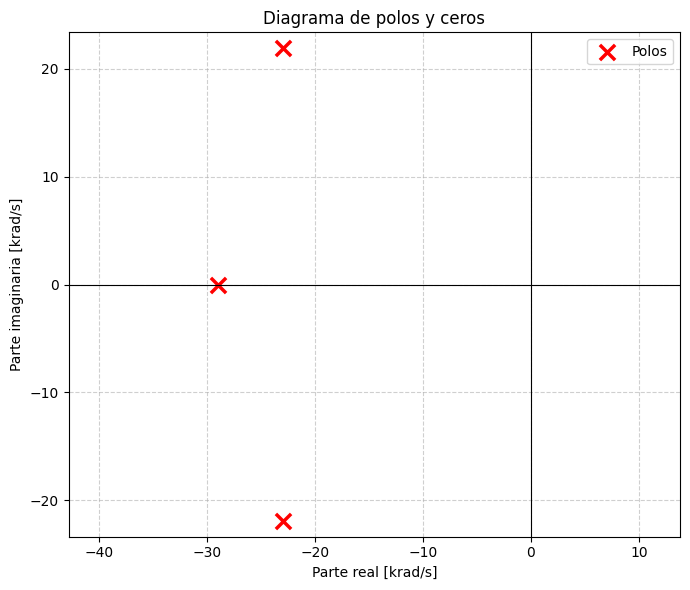

In [4]:
# ============================================================
# Diagrama de polos y ceros
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

# Se utiliza krad/s para que los valores sean más legibles
escala = 1e3

ax.scatter(
    polos.real / escala,
    polos.imag / escala,
    marker="x",
    s=120,
    linewidths=2.5,
    color="red",
    label="Polos"
)

if len(ceros) > 0:
    ax.scatter(
        ceros.real / escala,
        ceros.imag / escala,
        marker="o",
        s=100,
        facecolors="none",
        edgecolors="blue",
        linewidths=2,
        label="Ceros"
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(True, linestyle="--", alpha=0.6)

ax.set_xlabel(r"Parte real [krad/s]")
ax.set_ylabel(r"Parte imaginaria [krad/s]")
ax.set_title("Diagrama de polos y ceros")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Respuesta en frecuencia
# ============================================================

# Rango de frecuencias: 10 Hz a 100 kHz
f = np.logspace(1, 5, 5000)
w = 2 * np.pi * f

# Respuesta compleja H(jw)
w, H = signal.freqs(num, den, worN=w)

# Módulo
modulo_db = 20 * np.log10(np.abs(H))

# Fase desenvolvida
fase_rad = np.unwrap(np.angle(H))
fase_deg = np.rad2deg(fase_rad)

# Retardo de grupo:
# tau_g = -d(phi)/d(w)
retardo_grupo_s = -np.gradient(fase_rad, w)
retardo_grupo_us = retardo_grupo_s * 1e6

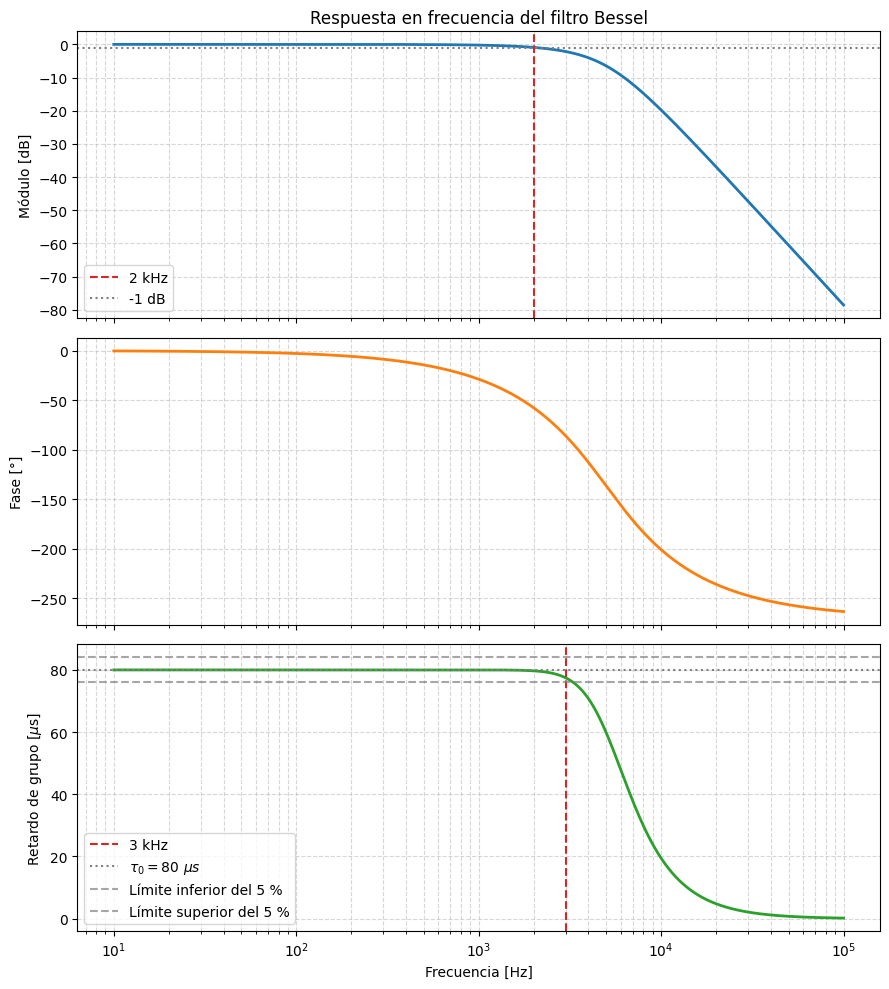

In [6]:
# ============================================================
# Gráficos de módulo, fase y retardo de grupo
# ============================================================

fig, ax = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True
)

# Módulo
ax[0].semilogx(
    f,
    modulo_db,
    color="tab:blue",
    linewidth=2
)

ax[0].axvline(
    2000,
    color="tab:red",
    linestyle="--",
    label="2 kHz"
)

ax[0].axhline(
    -1,
    color="gray",
    linestyle=":",
    label="-1 dB"
)

ax[0].set_ylabel("Módulo [dB]")
ax[0].set_title("Respuesta en frecuencia del filtro Bessel")
ax[0].grid(True, which="both", linestyle="--", alpha=0.5)
ax[0].legend()

# Fase
ax[1].semilogx(
    f,
    fase_deg,
    color="tab:orange",
    linewidth=2
)

ax[1].set_ylabel("Fase [°]")
ax[1].grid(True, which="both", linestyle="--", alpha=0.5)

# Retardo de grupo
ax[2].semilogx(
    f,
    retardo_grupo_us,
    color="tab:green",
    linewidth=2
)

ax[2].axvline(
    3000,
    color="tab:red",
    linestyle="--",
    label="3 kHz"
)

ax[2].axhline(
    80,
    color="gray",
    linestyle=":",
    label=r"$\tau_0=80\ \mu s$"
)

ax[2].axhline(
    76,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Límite inferior del 5 %"
)

ax[2].axhline(
    84,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Límite superior del 5 %"
)

ax[2].set_xlabel("Frecuencia [Hz]")
ax[2].set_ylabel(r"Retardo de grupo [$\mu$s]")
ax[2].grid(True, which="both", linestyle="--", alpha=0.5)
ax[2].legend()

plt.tight_layout()
plt.show()

# <ins> 2. Simulación LTSpice

### <ins> Circuito Utilizado
<div align="center">
    <img src="./Imagenes/FiltroDesnormalizadoIDEAL.png" alt="Circuito" width="900"/>
</div>

### <ins> Módulo y Fase 

<div align="center">
    <img src="./Imagenes/ModuloFaseIDEAL.png" alt="Módulo y Fase " width="1500"/>
</div>

#### <ins> Cursores

<div align="center">
    <img src="./Imagenes/CursorModulo2kIDEAL.png" alt="Cursor Módulo " width="300"/>
</div>

### <ins> Retardo de grupo 

<div align="center">
    <img src="./Imagenes/RetardoIDEAL.png" alt="Retardo de grupo" width="1500"/>
</div>

#### <ins> Cursores

<div align="center">
    <img src="./Imagenes/CursorRetardoIDEAL.png" alt="Cursor Retardo " width="300"/>
</div>

Se simuló el circuito obtenido en la síntesis teórica mediante un análisis AC entre $100\,\text{Hz}$ y $100\,\text{kHz}$. Se analizaron el módulo, la fase y el retardo de grupo.

La respuesta obtenida presenta el comportamiento esperado para un filtro Bessel pasabajos de tercer orden: módulo sin ondulaciones, fase que tiende a $-270^\circ$ y retardo aproximadamente constante dentro de la banda de interés.

### <ins>Comparación con los resultados teóricos

Los valores obtenidos mediante la simulación se comparan con los resultados calculados teóricamente:

| Magnitud | Valor teórico | Simulación LTspice |
|---|---:|---:|
| Atenuación a $2\,\text{kHz}$ | $0.913\,\text{dB}$ | $0.914\,\text{dB}$ |
| Retardo en baja frecuencia | $80\,\mu\text{s}$ | $80.033\,\mu\text{s}$ |
| Retardo a $3\,\text{kHz}$ | $77.46\,\mu\text{s}$ | $77.51\,\mu\text{s}$ |
| Desvío a $3\,\text{kHz}$ | $3.18\,\%$ | $3.12\,\%$ |

Las pequeñas diferencias entre los resultados teóricos y simulados se deben al redondeo de los valores de los componentes y a que los cursores no se ubicaron exactamente en $2\,\text{kHz}$ y $3\,\text{kHz}$.

La simulación confirma que el circuito cumple las especificaciones:

$$
A(2\,\text{kHz})<1\,\text{dB}
$$

$$
\text{Desvío de }\tau_g(3\,\text{kHz})<5\,\%
$$

Por lo tanto, el circuito sintetizado reproduce correctamente la transferencia Bessel de tercer orden obtenida en el desarrollo teórico.

----
# <ins> 3. Armado y selección de componentes

Para implementar la etapa de primer orden se utilizó una resistencia fija de $33\,\text{k}\Omega$ en serie con un potenciómetro multivuelta de $10\,\text{k}\Omega$. Esta combinación permitió ajustar el valor de la resistencia alrededor del valor teórico calculado. Como capacitor se utilizó uno de poliéster de $1\,\text{nF}$.

Para la celda Sallen-Key se utilizaron:

- una resistencia de $21\,\text{k}\Omega$ en serie con un potenciómetro lineal de $5\,\text{k}\Omega$;
- una resistencia de $12\,\text{k}\Omega$ en serie con un potenciómetro multivuelta de $10\,\text{k}\Omega$;
- un capacitor cerámico de $2.2\,\text{nF}$;
- un capacitor de poliéster de $1\,\text{nF}$.

Los dos seguidores de tensión se implementaron mediante un amplificador operacional doble TL082CP.

<div align="center">
    <img src="./Imagenes/circuito.png" alt="Circuito " width="400"/>
</div>






## <ins> Instrumental utilizado

Para alimentar el circuito, generar la señal de entrada y efectuar las mediciones se utilizaron los siguientes instrumentos:

| Instrumento | Marca y modelo | Código de inventario |
|---|---|---:|
| Osciloscopio digital | GW Instek GDS-1072A-U | NG1396 |
| Fuente regulable de corriente continua | DC Power Supply HY3005D | NG1357 |
| Fuente regulable de corriente continua | DC Power Supply HY3005D | NG1354 |
| Generador de señales | Twintex TFG-3205E | NG1903 |
| Tester | UNI-T UT61 | NG1821 |

<div align="center">
    <img src="./Imagenes/Instrumentos/Osciloscopio.jpeg" alt="Osciloscopio " width="800"/>
</div>

<div align="center">
    <img src="./Imagenes/Instrumentos/Fuentes y Generador.png" alt="Fuentes y Generador " width="800"/>
</div>

<div align="center">
    <img src="./Imagenes/Instrumentos/Tester.jpeg" alt="Multimetro" width="300"/>
</div>

Las dos fuentes regulables se utilizaron para obtener la alimentación positiva y negativa necesaria para el amplificador operacional TL082CP.

## <ins> Conexión del circuito y los instrumentos

Las dos fuentes de corriente continua se conectaron para obtener una alimentación simétrica. Se estableció un punto común como referencia o masa del circuito, obteniéndose respecto de él una tensión de alimentación positiva $+V_{CC}$ y una tensión negativa $-V_{CC}$.

Las conexiones se realizaron de la siguiente manera:

- la salida positiva de una de las fuentes se conectó a la alimentación positiva del TL082CP;
- la salida negativa de la otra fuente se conectó a la alimentación negativa del TL082CP;
- el punto común de las fuentes se utilizó como masa del circuito;
- la salida del generador de señales se conectó a la entrada del filtro;
- la masa del generador se conectó a la masa común;
- el canal 1 del osciloscopio se conectó a la entrada del filtro para medir $V_{in}$;
- el canal 2 del osciloscopio se conectó a la salida del filtro para medir $V_o$;
- las referencias de ambos canales del osciloscopio se conectaron a la misma masa del circuito.

<div align="center">
    <img src="./Imagenes/Diagrama conexion.png" alt="Conexiones" width="800"/>
</div>

De esta forma fue posible visualizar simultáneamente las señales de entrada y salida, medir sus amplitudes pico a pico y determinar la diferencia temporal entre ellas.

### <ins> Valores reales de los componentes

Antes de efectuar el ajuste se midieron los capacitores utilizados en el circuito. Los valores obtenidos fueron:

| Componente | Valor nominal | Valor medido |
|---|---:|---:|
| $C_1$ | $1\,\text{nF}$ | $1.01\,\text{nF}$ |
| $C_2$ | $2.2\,\text{nF}$ | $2.14\,\text{nF}$ |
| $C_3$ | $1\,\text{nF}$ | $1.07\,\text{nF}$ |

Una vez colocados los capacitores reales, se ajustaron los potenciómetros observando la respuesta del circuito. Los valores finales de las resistencias fueron:

| Componente | Implementación | Valor ajustado |
|---|---|---:|
| $R_1$ | $33\,\text{k}\Omega + P_1$ de $10\,\text{k}\Omega$ | $33.771\,\text{k}\Omega$ |
| $R_2$ | $21\,\text{k}\Omega + P_2$ de $5\,\text{k}\Omega$ | $26.630\,\text{k}\Omega$ |
| $R_3$ | $12\,\text{k}\Omega + P_3$ de $10\,\text{k}\Omega$ | $17.170\,\text{k}\Omega$ |

Estos valores fueron utilizados para representar el comportamiento del circuito real en LTspice.

---
# <ins> 4. Mediciones con osciloscopio

Se aplicó una señal senoidal al filtro y se realizó un barrido manual de frecuencia. Para cada punto se midieron:

- la frecuencia de la señal;
- la tensión pico a pico de entrada $V_{in}$;
- la tensión pico a pico de salida $V_o$;
- la diferencia temporal $\Delta t$ entre ambas señales.

Las 21 mediciones obtenidas se presentan a continuación.

### <ins> Datos obtenidos

| Frecuencia [Hz] | $V_{in}$ [Vpp] | $V_o$ [Vpp] | Delay [$\mu$s] |
|---:|---:|---:|---:|
| 200 | 20.7 | 20.7 | 110 |
| 400 | 20.7 | 20.7 | 108 |
| 600 | 20.7 | 20.0 | 104 |
| 800 | 20.7 | 20.0 | 94 |
| 1000 | 20.7 | 19.6 | 92 |
| 1200 | 20.7 | 19.2 | 90 |
| 1400 | 20.7 | 19.2 | 86 |
| 1600 | 20.7 | 18.3 | 85 |
| 1800 | 20.7 | 18.0 | 81 |
| 2000 | 20.7 | 18.0 | 81 |
| 2500 | 20.7 | 17.2 | 84 |
| 3000 | 20.7 | 15.1 | 83 |
| 3500 | 20.7 | 14.0 | 82 |
| 4000 | 20.7 | 12.3 | 81 |
| 5000 | 20.7 | 9.6 | 77 |
| 6000 | 20.7 | 8.0 | 77 |
| 7000 | 20.7 | 5.0 | 73 |
| 8000 | 20.7 | 3.79 | 64 |
| 10000 | 20.7 | 2.0 | 58 |
| 30000 | 20.7 | 0.09 | 23 |
| 100000 | 20.7 | 0.003 | 7.5 |

### <ins> Cálculo del módulo y la fase

A partir de las tensiones pico a pico, el módulo lineal de la transferencia se calcula como

$$
|H(f)|=\frac{V_o}{V_{in}}.
$$

El módulo expresado en decibeles resulta

$$
M(f)=20\log_{10}\left(\frac{V_o}{V_{in}}\right).
$$

La fase se obtiene a partir de la diferencia temporal medida entre la entrada y la salida. Como la salida se encuentra retrasada respecto de la entrada:

$$
\phi(f)=-\omega\Delta t=-2\pi f\Delta t.
$$

Si $\Delta t$ se expresa en microsegundos, la fase en grados se calcula mediante

$$
\phi(f)[^\circ]
=
-360^\circ f\left(\Delta t\cdot10^{-6}\right).
$$

La demora medida directamente en el osciloscopio corresponde al retardo de fase. El retardo de grupo, en cambio, se define como

$$
\tau_g(\omega)=-\frac{d\phi(\omega)}{d\omega}.
$$

Como la derivación directa de puntos experimentales amplifica los errores de medición, primero se ajusta una función transferencia continua a las curvas de módulo y fase. Luego se calcula el retardo de grupo de esa transferencia.

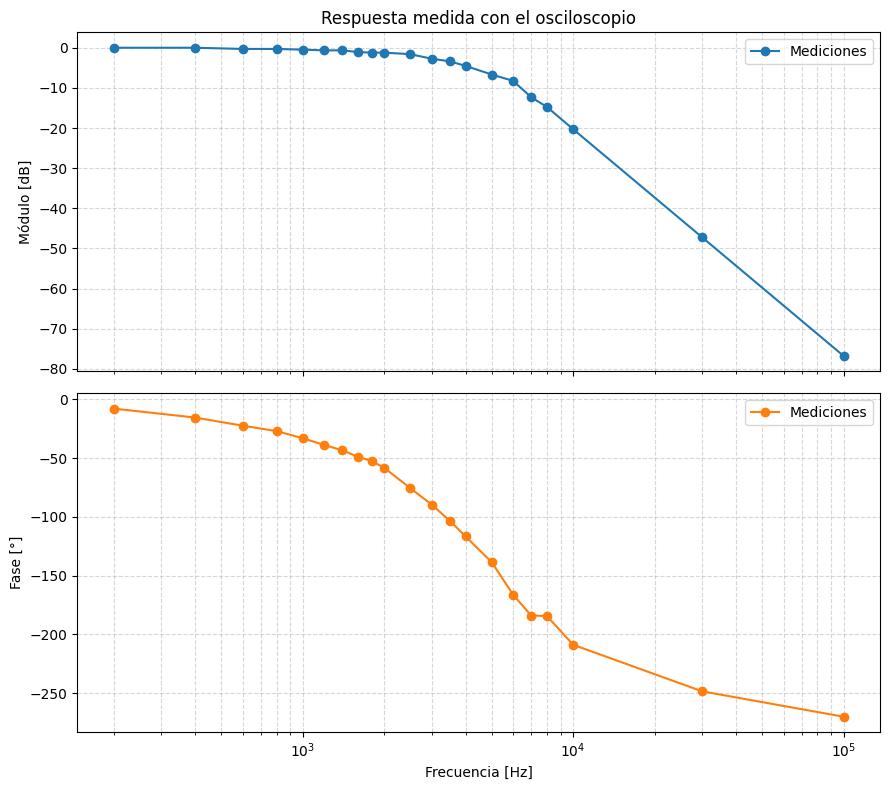

In [7]:
# Datos medidos
frecuencia = np.array([
    200, 400, 600, 800, 1000, 1200, 1400,
    1600, 1800, 2000, 2500, 3000, 3500,
    4000, 5000, 6000, 7000, 8000, 10000,
    30000, 100000
], dtype=float)

Vin = np.array([
    20.7, 20.7, 20.7, 20.7, 20.7, 20.7, 20.7,
    20.7, 20.7, 20.7, 20.7, 20.7, 20.7, 20.7,
    20.7, 20.7, 20.7, 20.7, 20.7, 20.7, 20.7
], dtype=float)

Vo = np.array([
    20.7, 20.7, 20.0, 20.0, 19.6, 19.2, 19.2,
    18.3, 18.0, 18.0, 17.2, 15.1, 14.0, 12.3,
    9.6, 8.0, 5.0, 3.79, 2.0, 0.09, 0.003
], dtype=float)

delay_us = np.array([
    110, 108, 104, 94, 92, 90, 86,
    85, 81, 81, 84, 83, 82, 81,
    77, 77, 73, 64, 58, 23, 7.5
], dtype=float)

# Módulo lineal y en dB
modulo_lineal = Vo / Vin
modulo_db = 20*np.log10(modulo_lineal)

# Conversión del delay a segundos
delay_s = delay_us * 1e-6

# Fase
fase_rad = -2*np.pi*frecuencia*delay_s
fase_deg = np.rad2deg(fase_rad)

# Gráficos experimentales
fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax[0].semilogx(
    frecuencia,
    modulo_db,
    "o-",
    color="tab:blue",
    label="Mediciones"
)

ax[0].set_ylabel("Módulo [dB]")
ax[0].set_title("Respuesta medida con el osciloscopio")
ax[0].grid(True, which="both", linestyle="--", alpha=0.5)
ax[0].legend()

ax[1].semilogx(
    frecuencia,
    fase_deg,
    "o-",
    color="tab:orange",
    label="Mediciones"
)

ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Fase [°]")
ax[1].grid(True, which="both", linestyle="--", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

### Ajuste de la función transferencia

Para ajustar las mediciones se adopta una transferencia pasabajos de tercer orden con la misma estructura que el circuito implementado:

$$
H_{\mathrm{aj}}(s)
=
\frac{p_1\omega_0^2}
{(s+p_1)
\left(
s^2+\dfrac{\omega_0}{Q}s+\omega_0^2
\right)}.
$$

Los parámetros a determinar son:

- $p_1$: frecuencia angular del polo real;
- $\omega_0$: frecuencia natural de la etapa de segundo orden;
- $Q$: factor de calidad de la etapa de segundo orden.

El ajuste se realiza simultáneamente sobre el módulo y la fase. Se mantiene ganancia unitaria en continua, de acuerdo con la topología del filtro.

Parámetros ajustados
p1 = 27373.16 rad/s
w0 = 32129.66 rad/s
Q  = 0.69133

Numerador:
[2.82577311e+13]

Denominador:
[1.00000000e+00 7.38480389e+04 2.30447954e+09 2.82577311e+13]


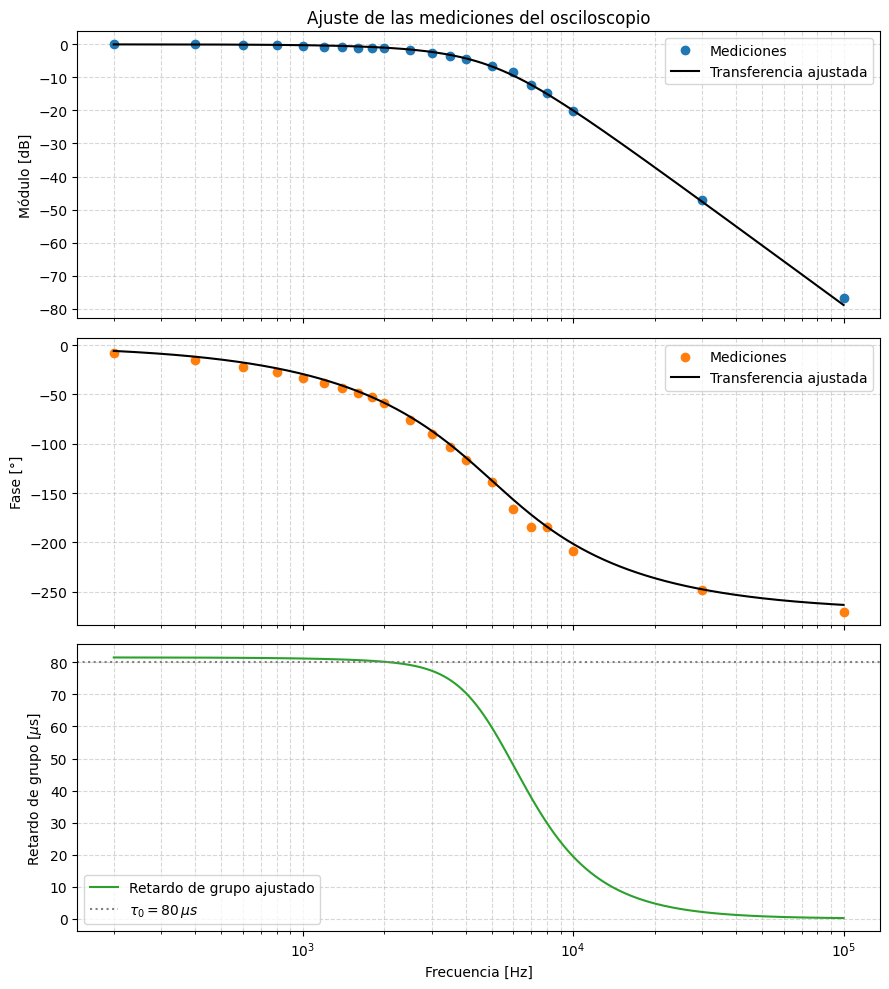

In [8]:
# ============================================================
# Modelo de tercer orden
# ============================================================

def respuesta_modelo(f, theta):
    """
    theta contiene los logaritmos de p1, w0 y Q.
    Esto asegura que los tres parámetros sean positivos.
    """
    p1, w0, Q = np.exp(theta)

    s = 1j*2*np.pi*np.asarray(f)

    H = (
        p1*w0**2
        /
        (
            (s+p1) *
            (s**2+(w0/Q)*s+w0**2)
        )
    )

    return H


# ============================================================
# Función de error
# ============================================================

def residuos(theta):
    H = respuesta_modelo(frecuencia, theta)

    modulo_modelo_db = 20*np.log10(np.abs(H))
    fase_modelo_deg = np.rad2deg(
        np.unwrap(np.angle(H))
    )

    # Pesos asociados a la incertidumbre de las mediciones
    error_modulo = (modulo_modelo_db-modulo_db) / 0.5
    error_fase = (fase_modelo_deg-fase_deg) / 4.0

    return np.concatenate([
        error_modulo,
        error_fase
    ])


# Valores iniciales obtenidos del diseño teórico
p1_inicial = 29027.3
w0_inicial = 31769.3
Q_inicial = 0.691

theta_inicial = np.log([
    p1_inicial,
    w0_inicial,
    Q_inicial
])

resultado = least_squares(
    residuos,
    theta_inicial,
    loss="linear"
)

p1_aj, w0_aj, Q_aj = np.exp(resultado.x)

# ============================================================
# Coeficientes de la transferencia ajustada
# ============================================================

a_aj = w0_aj / Q_aj

num_aj = np.array([
    p1_aj*w0_aj**2
])

den_aj = np.array([
    1,
    p1_aj+a_aj,
    w0_aj**2+p1_aj*a_aj,
    p1_aj*w0_aj**2
])

H_ajustada = TransferFunction(
    num_aj,
    den_aj
)

print("Parámetros ajustados")
print(f"p1 = {p1_aj:.2f} rad/s")
print(f"w0 = {w0_aj:.2f} rad/s")
print(f"Q  = {Q_aj:.5f}")

print("\nNumerador:")
print(num_aj)

print("\nDenominador:")
print(den_aj)


# ============================================================
# Curvas de la transferencia ajustada
# ============================================================

f_grafico = np.logspace(
    np.log10(frecuencia.min()),
    np.log10(frecuencia.max()),
    2000
)

H_grafico = respuesta_modelo(
    f_grafico,
    resultado.x
)

modulo_aj_db = 20*np.log10(
    np.abs(H_grafico)
)

fase_aj_deg = np.rad2deg(
    np.unwrap(np.angle(H_grafico))
)


# ============================================================
# Retardo de grupo analítico
# ============================================================

def retardo_grupo(f, p1, w0, Q):
    w = 2*np.pi*np.asarray(f)
    a = w0/Q

    tau_primer_orden = (
        p1 / (p1**2+w**2)
    )

    tau_segundo_orden = (
        a*(w0**2+w**2)
        /
        (
            (w0**2-w**2)**2
            +(a*w)**2
        )
    )

    return tau_primer_orden + tau_segundo_orden


tau_aj_us = (
    retardo_grupo(
        f_grafico,
        p1_aj,
        w0_aj,
        Q_aj
    )
    * 1e6
)


# ============================================================
# Gráficos medidos y ajustados
# ============================================================

fig, ax = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True
)

# Módulo
ax[0].semilogx(
    frecuencia,
    modulo_db,
    "o",
    color="tab:blue",
    label="Mediciones"
)

ax[0].semilogx(
    f_grafico,
    modulo_aj_db,
    "-",
    color="black",
    label="Transferencia ajustada"
)

ax[0].set_ylabel("Módulo [dB]")
ax[0].set_title("Ajuste de las mediciones del osciloscopio")
ax[0].grid(True, which="both", linestyle="--", alpha=0.5)
ax[0].legend()

# Fase
ax[1].semilogx(
    frecuencia,
    fase_deg,
    "o",
    color="tab:orange",
    label="Mediciones"
)

ax[1].semilogx(
    f_grafico,
    fase_aj_deg,
    "-",
    color="black",
    label="Transferencia ajustada"
)

ax[1].set_ylabel("Fase [°]")
ax[1].grid(True, which="both", linestyle="--", alpha=0.5)
ax[1].legend()

# Retardo de grupo
ax[2].semilogx(
    f_grafico,
    tau_aj_us,
    color="tab:green",
    label="Retardo de grupo ajustado"
)

ax[2].axhline(
    80,
    color="gray",
    linestyle=":",
    label=r"$\tau_0=80\,\mu s$"
)

ax[2].set_xlabel("Frecuencia [Hz]")
ax[2].set_ylabel(r"Retardo de grupo [$\mu$s]")
ax[2].grid(True, which="both", linestyle="--", alpha=0.5)
ax[2].legend()

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Evaluación de valores característicos del ajuste
# ============================================================

# Frecuencias de evaluación
f_modulo = 2000.0       # Hz
f_retardo = 3000.0      # Hz

# ------------------------------------------------------------
# Módulo a 2 kHz
# ------------------------------------------------------------

H_2k = respuesta_modelo(
    np.array([f_modulo]),
    resultado.x
)[0]

modulo_2k_db = 20*np.log10(
    np.abs(H_2k)
)

atenuacion_2k_db = -modulo_2k_db


# ------------------------------------------------------------
# Retardo de grupo en baja frecuencia
# ------------------------------------------------------------

# Se evalúa en continua: f = 0 Hz
retardo_baja_us = retardo_grupo(
    np.array([0.0]),
    p1_aj,
    w0_aj,
    Q_aj
)[0] * 1e6


# ------------------------------------------------------------
# Retardo de grupo a 3 kHz
# ------------------------------------------------------------

retardo_3k_us = retardo_grupo(
    np.array([f_retardo]),
    p1_aj,
    w0_aj,
    Q_aj
)[0] * 1e6


# ------------------------------------------------------------
# Desvío respecto de 80 µs
# ------------------------------------------------------------

desvio_3k = (
    abs(retardo_3k_us - 80.0) / 80.0
) * 100


# ------------------------------------------------------------
# Desvío respecto BF
# ------------------------------------------------------------

desvio_BF = (
    abs(retardo_3k_us - retardo_baja_us) / retardo_baja_us
) * 100

# ------------------------------------------------------------
# Presentación de resultados
# ------------------------------------------------------------

print("\nValores característicos de la transferencia ajustada")
print("---------------------------------------------------")

print(
    f"Módulo a 2 kHz: "
    f"{modulo_2k_db:.3f} dB"
)

print(
    f"Atenuación a 2 kHz: "
    f"{atenuacion_2k_db:.3f} dB"
)

print(
    f"Retardo de grupo en baja frecuencia: "
    f"{retardo_baja_us:.3f} µs"
)

print(
    f"Retardo de grupo a 3 kHz: "
    f"{retardo_3k_us:.3f} µs"
)

print(
    f"Desvío del retardo a 3 kHz: "
    f"{desvio_3k:.3f} %"
)

print(
    f"Desvío del retardo a 3 kHz con respecto a Baja Frecuencia: "
    f"{desvio_BF:.3f} %"
)


Valores característicos de la transferencia ajustada
---------------------------------------------------
Módulo a 2 kHz: -0.991 dB
Atenuación a 2 kHz: 0.991 dB
Retardo de grupo en baja frecuencia: 81.552 µs
Retardo de grupo a 3 kHz: 77.393 µs
Desvío del retardo a 3 kHz: 3.259 %
Desvío del retardo a 3 kHz con respecto a Baja Frecuencia: 5.101 %


---

# <ins>5. Simulación LTSpice Modelo REAL


### <ins> Circuito Utilizado
<div align="center">
    <img src="./Imagenes/CtoRealLtspice.png" alt="Circuito" width="900"/>
</div>

## <ins> Módulo y Fase 

<div align="center">
    <img src="./Imagenes/Modulo y Fase Real.png" alt="Módulo y Fase " width="1500"/>
</div>

#### <ins> Cursores

<div align="center">
    <img src="./Imagenes/CursorModulo2kREAL.png" alt="Cursor Módulo " width="300"/>
</div>

### <ins> Retardo de grupo 

<div align="center">
    <img src="./Imagenes/RetardoREAL.png" alt="Retardo de grupo" width="1500"/>
</div>

#### <ins> Cursores

<div align="center">
    <img src="./Imagenes/CursorRetardoREAL.png" alt="Cursor Retardo " width="300"/>
</div>

## <ins>Comparación entre los resultados ideales, reales y medidos

Se compararon los siguientes casos:

1. **Simulación ideal:** utiliza los valores calculados durante la síntesis.
2. **Simulación real:** utiliza los valores medidos de los capacitores y las resistencias ajustadas.
3. **Respuesta medida:** se obtiene a partir de $V_{in}$, $V_o$ y el delay registrados con el osciloscopio.

Para el módulo y la fase se muestran tanto los puntos medidos como los valores de la transferencia ajustada. El retardo de grupo medido se obtiene exclusivamente de esta transferencia, ya que el delay indicado por el osciloscopio corresponde al retardo de fase y no directamente al retardo de grupo.

| Magnitud | Simulación ideal | Simulación real | Medición directa | Transferencia ajustada |
|---|---:|---:|---:|---:|
| Módulo a $2\,\text{kHz}$ | $-0.914\,\text{dB}$ | $-0.917\,\text{dB}$ | $-1.214\,\text{dB}$ | $-0.991\,\text{dB}$ |
| Fase a $2\,\text{kHz}$ | $-57.66^\circ$ | $-58.44^\circ$ | $-58.32^\circ$ | $-58.40^\circ$ |
| Retardo de grupo a $2\,\text{kHz}$ | $79.76\,\mu\text{s}$ | $81.20\,\mu\text{s}$ | — | $80.20\,\mu\text{s}$ |
| Módulo a $3\,\text{kHz}$ | $-2.168\,\text{dB}$ | $-2.210\,\text{dB}$ | $-2.740\,\text{dB}$ | $-2.293\,\text{dB}$ |
| Fase a $3\,\text{kHz}$ | $-86.16^\circ$ | $-87.53^\circ$ | $-89.64^\circ$ | $-86.85^\circ$ |
| Retardo de grupo a $3\,\text{kHz}$ | $77.51\,\mu\text{s}$ | $78.91\,\mu\text{s}$ | — | $77.39\,\mu\text{s}$ |
| Retardo de grupo en continua | $80.03\,\mu\text{s}$ | $81.01\,\mu\text{s}$ | — | $81.55\,\mu\text{s}$ |

La simulación con componentes reales mantiene una respuesta muy próxima a la simulación ideal. A $2\,\text{kHz}$ la diferencia de módulo entre ambas simulaciones es de aproximadamente $0.003\,\text{dB}$, mientras que la diferencia de fase es menor a $1^\circ$. Esto indica que el ajuste de las resistencias compensó adecuadamente las diferencias introducidas por los valores reales de los capacitores.

Los puntos medidos presentan una dispersión mayor, especialmente en el módulo. A $2\,\text{kHz}$ se midió una atenuación de $1.214\,\text{dB}$, mientras que la transferencia ajustada predice aproximadamente $0.991\,\text{dB}$. Esta diferencia se relaciona con la resolución de las lecturas de tensión, ya que pequeñas variaciones en $V_o$ producen diferencias apreciables al calcular el módulo en decibeles.

En la fase se observa una mejor correspondencia. A $2\,\text{kHz}$ se midieron $-58.32^\circ$, frente a $-58.44^\circ$ en la simulación real. A $3\,\text{kHz}$ la diferencia entre la medición y la simulación real es de aproximadamente $2.1^\circ$.

La transferencia ajustada conserva el comportamiento esperado del retardo de grupo. A $3\,\text{kHz}$ se obtiene

$$
\tau_{g,\mathrm{aj}}(3\,\text{kHz})
\approx77.39\,\mu\text{s}.
$$

$$
\varepsilon_\tau
=
\frac{|81.55-77.39|}{81.55}\cdot100
\approx5.1\%
$$

Su desvío respecto del valor nominal es

$$
\text{Desvío}
=
\left|
\frac{77.39-80}{80}
\right|100
\approx3.26\,\%.
$$

Como este resultado es menor que el límite del $5\,\%$, la respuesta obtenida a partir de las mediciones cumple la especificación de retardo de grupo.

En conclusión, las simulaciones ideal y real presentan resultados muy próximos. Las mediciones siguen la misma tendencia general, aunque muestran mayor dispersión por la resolución de los instrumentos, el ajuste manual, las tolerancias de los componentes y los efectos no ideales del montaje. El ajuste conjunto de módulo y fase permite reducir esa dispersión y obtener una transferencia representativa del comportamiento experimental.

---
# <ins> 6. Mediciones con el analizador de audio

Para obtener una medición automática de la respuesta en frecuencia del filtro se utilizó un analizador de audio **Agilent Technologies U8903A**, identificado con el código de inventario **NG1652**.

<div align="center">
    <img src="./Imagenes/Instrumentos/AnalizadorAudio.png" alt="Analizador de Audio" width="500"/>
</div>

El instrumento realizó un barrido en frecuencia y exportó los resultados en dos archivos:

- `fase.csv`, que contiene la fase medida en función de la frecuencia;
- `modulo.csv`, que contiene el módulo medido en función de la frecuencia.


### <ins> Datos de fase

El bloque útil del archivo `fase.csv` se encuentra identificado como `Phase vs Frequency`. Los datos exportados y la fase corregida son:

| Frecuencia [Hz] | Fase original [°] | Fase corregida [°] |
|---:|---:|---:|
| 5.000 | -0.523 | -0.523 |
| 6.056 | 0.121 | 0.121 |
| 7.336 | -0.398 | -0.398 |
| 8.886 | -0.019 | -0.019 |
| 10.764 | 0.042 | 0.042 |
| 13.038 | -0.537 | -0.537 |
| 15.793 | -0.493 | -0.493 |
| 19.130 | -0.526 | -0.526 |
| 23.172 | -0.619 | -0.619 |
| 28.068 | -0.813 | -0.813 |
| 33.998 | -0.971 | -0.971 |
| 41.182 | -1.189 | -1.189 |
| 49.883 | -1.480 | -1.480 |
| 60.423 | -1.786 | -1.786 |
| 73.190 | -2.193 | -2.193 |
| 88.654 | -2.666 | -2.666 |
| 107.386 | -3.227 | -3.227 |
| 130.076 | -3.905 | -3.905 |
| 157.560 | -4.724 | -4.724 |
| 190.851 | -5.712 | -5.712 |
| 231.176 | -6.906 | -6.906 |
| 280.021 | -8.347 | -8.347 |
| 339.187 | -10.089 | -10.089 |
| 410.854 | -12.193 | -12.193 |
| 497.664 | -14.733 | -14.733 |
| 602.816 | -17.802 | -17.802 |
| 730.186 | -21.509 | -21.509 |
| 884.468 | -25.984 | -25.984 |
| 1071.348 | -31.389 | -31.389 |
| 1297.715 | -37.916 | -37.916 |
| 1571.911 | -45.797 | -45.797 |
| 1904.042 | -55.315 | -55.315 |
| 2306.349 | -66.803 | -66.803 |
| 2793.661 | -80.645 | -80.645 |
| 3383.937 | -97.078 | -97.078 |
| 4098.934 | -116.049 | -116.049 |
| 4965.003 | -136.759 | -136.759 |
| 6014.065 | -157.474 | -157.474 |
| 7284.784 | -176.433 | -176.433 |
| 8823.996 | 167.228 | -192.772 |
| 10688.429 | 153.713 | -206.287 |
| 12946.801 | 142.638 | -217.362 |
| 15682.347 | 133.548 | -226.452 |
| 18995.891 | 126.092 | -233.908 |
| 23009.557 | 119.933 | -240.067 |
| 27871.277 | 114.741 | -245.259 |
| 33760.235 | 110.296 | -249.704 |
| 40893.479 | 106.267 | -253.733 |
| 49533.915 | 102.419 | -257.581 |
| 60000.000 | 98.262 | -261.738 |

### <ins> Corrección del salto de fase

La fase exportada por el analizador está representada dentro del intervalo comprendido entre $-180^\circ$ y $+180^\circ$. Por este motivo aparece un salto entre las siguientes mediciones:

$$
\phi(7284.8\,\text{Hz})=-176.43^\circ,
$$

$$
\phi(8824.0\,\text{Hz})=+167.23^\circ.
$$

Este salto no representa una discontinuidad física. La fase continúa disminuyendo y el valor correcto después del salto es

$$
167.23^\circ-360^\circ=-192.77^\circ.
$$

La corrección se realizó mediante un desenvolvimiento de fase:

$$
\phi_{\mathrm{corr}}(f)
=
\operatorname{unwrap}\left[\phi_{\mathrm{med}}(f)\right].
$$

El procedimiento suma o resta múltiplos de $360^\circ$ cuando detecta un salto artificial, obteniendo una curva continua que tiende progresivamente a $-270^\circ$, como corresponde a un filtro pasabajos de tercer orden.


### <ins> Datos de módulo

El bloque útil del archivo `modulo.csv` se encuentra identificado como `Vac vs Frequency`. Los valores originales y corregidos son:

| Frecuencia [Hz] | Módulo original [dBr] | Módulo corregido [dB] |
|---:|---:|---:|
| 5.000 | 54.125 | 0.125 |
| 6.912 | 54.245 | 0.245 |
| 9.556 | 54.357 | 0.357 |
| 13.212 | 54.435 | 0.435 |
| 18.265 | 54.455 | 0.455 |
| 25.251 | 54.476 | 0.476 |
| 34.909 | 54.484 | 0.484 |
| 48.261 | 54.495 | 0.495 |
| 66.721 | 54.493 | 0.493 |
| 92.241 | 54.491 | 0.491 |
| 127.522 | 54.493 | 0.493 |
| 176.297 | 54.476 | 0.476 |
| 243.729 | 54.463 | 0.463 |
| 336.952 | 54.446 | 0.446 |
| 465.833 | 54.410 | 0.410 |
| 644.008 | 54.351 | 0.351 |
| 890.334 | 54.247 | 0.247 |
| 1230.876 | 54.063 | 0.063 |
| 1701.671 | 53.725 | -0.275 |
| 2352.540 | 53.084 | -0.916 |
| 3252.359 | 51.808 | -2.192 |
| 4496.348 | 49.179 | -4.821 |
| 6216.147 | 44.485 | -9.515 |
| 8593.750 | 37.860 | -16.140 |
| 11880.758 | 30.245 | -23.755 |
| 16425.007 | 22.183 | -31.817 |
| 22707.378 | 13.930 | -40.070 |
| 31392.681 | 5.565 | -48.435 |
| 43400.010 | -2.827 | -56.827 |
| 60000.000 | -10.805 | -64.805 |

### <ins>Corrección del módulo

Los valores exportados presentan un offset conocido de $54\,\text{dB}$. Por lo tanto, la corrección aplicada fue

$$
M_{\mathrm{corr}}(f)
=
M_{\mathrm{CSV}}(f)-54\,\text{dB}.
$$

Se restaron exactamente $54\,\text{dB}$ y no el promedio de la banda pasante. Después de esta corrección, la meseta entre aproximadamente $25$ y $200\,\text{Hz}$ queda alrededor de

$$
M_{\mathrm{meseta}}\approx+0.487\,\text{dB}.
$$

Este valor residual se conservó como parte de la medición. En el ajuste se representa mediante una ganancia $G$, evitando normalizar artificialmente la curva a $0\,\text{dB}$.

Los primeros puntos del barrido muestran una pequeña variación a frecuencias muy bajas. Esta variación no se eliminó ni se modificó, ya que forma parte de los datos entregados por el instrumento.

### <ins>Ajuste conjunto de módulo y fase

Para obtener una función transferencia continua se utilizó un modelo de tercer orden con la misma estructura del circuito:

$$
H_{\mathrm{aj}}(s)
=
G
\frac{p_1\omega_0^2}
{(s+p_1)
\left(
s^2+\dfrac{\omega_0}{Q}s+\omega_0^2
\right)}.
$$

Los parámetros ajustados son:

- $G$: ganancia residual en continua;
- $p_1$: frecuencia angular del polo real;
- $\omega_0$: frecuencia natural de la etapa Sallen-Key;
- $Q$: factor de calidad de la etapa Sallen-Key.

Para cada conjunto tentativo de parámetros se evaluó la transferencia en las frecuencias medidas. Luego se compararon simultáneamente el módulo calculado y la fase calculada con los datos corregidos.

El ajuste minimiza la suma cuadrática de los errores normalizados:

$$
J
=
\sum_i
\left(
\frac{M_{\mathrm{aj}}(f_i)-M_{\mathrm{med}}(f_i)}
{0.15\,\text{dB}}
\right)^2
+
\sum_i
\left(
\frac{\phi_{\mathrm{aj}}(f_i)-\phi_{\mathrm{med}}(f_i)}
{1.5^\circ}
\right)^2.
$$

La normalización evita que la fase domine numéricamente al módulo por estar expresadas en unidades diferentes.

Una vez obtenida la transferencia se calculó el retardo de grupo mediante

$$
\tau_g(\omega)
=
-\frac{d\phi(\omega)}{d\omega}.
$$

El retardo se calcula sobre la función ajustada y no derivando directamente los puntos experimentales, ya que la derivación amplifica el ruido y las pequeñas variaciones de la medición.

Cantidad de datos leídos:
Fase: 50 puntos
Módulo: 30 puntos

Saltos de fase encontrados:

Entre 7284.78 Hz y 8824.00 Hz
Fase original: -176.43° → 167.23°
Fase corregida: -176.43° → -192.77°

Corrección del módulo:
Offset restado: 54.000 dB
Promedio original entre 25 Hz y 200 Hz: 54.487 dBr
Promedio corregido entre 25 Hz y 200 Hz: 0.487 dB


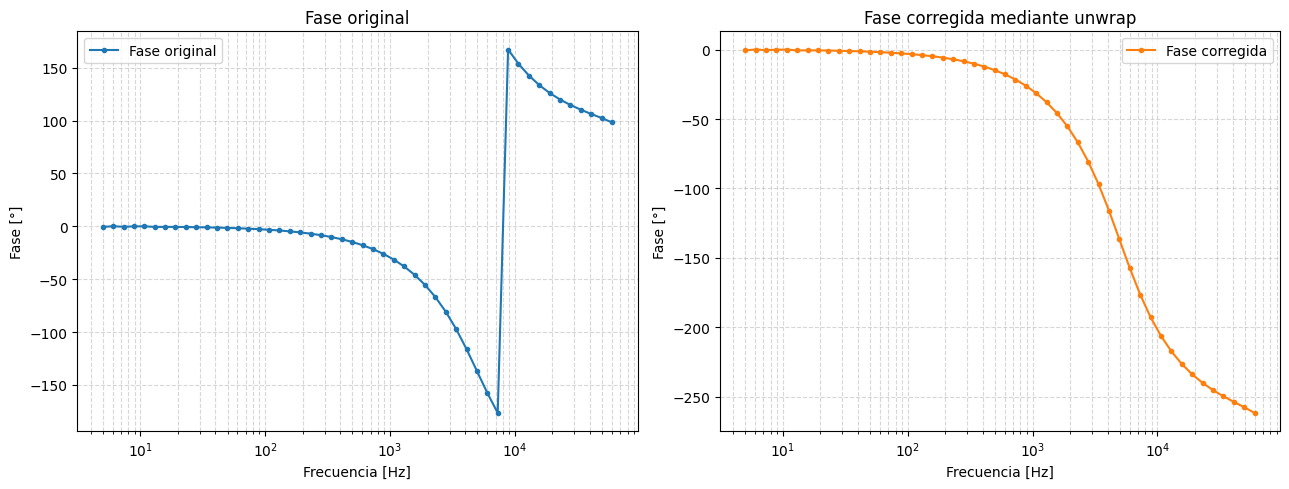

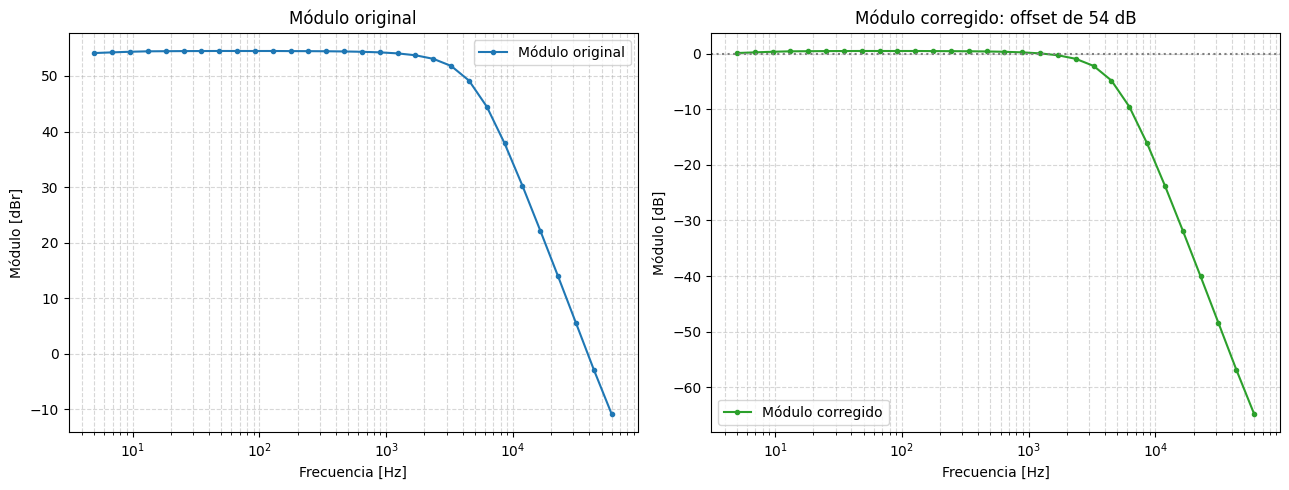

In [10]:
# ============================================================
# Función para leer un bloque dentro de un archivo CSV
# ============================================================

def leer_bloque_csv(ruta, marcador):
    """
    Busca dentro del CSV el bloque indicado por 'marcador'
    y devuelve los datos como un arreglo de NumPy.
    """

    with open(
        ruta,
        mode="r",
        encoding="utf-8-sig",
        newline=""
    ) as archivo:

        filas = list(csv.reader(archivo))

    # Buscar la fila donde comienza el bloque solicitado
    inicio = next(
        i for i, fila in enumerate(filas)
        if fila and marcador in fila[0]
    )

    # La fila siguiente contiene los encabezados.
    # Los datos comienzan dos filas después del marcador.
    datos = []

    for fila in filas[inicio + 2:]:

        # Una fila vacía indica el final del bloque
        if not fila:
            break

        datos.append([
            float(valor) for valor in fila
        ])

    return np.asarray(datos, dtype=float)


# ============================================================
# Lectura directa desde la carpeta Mediciones
# ============================================================

datos_fase = leer_bloque_csv(
    "Mediciones/fase.csv",
    "Phase vs Frequency"
)

datos_modulo = leer_bloque_csv(
    "Mediciones/modulo.csv",
    "Vac vs Frequency"
)

print("Cantidad de datos leídos:")
print(f"Fase: {len(datos_fase)} puntos")
print(f"Módulo: {len(datos_modulo)} puntos")


# ============================================================
# Separación de las columnas
# ============================================================

# fase.csv:
# columna 0 = frecuencia
# columna 1 = fase de CH1
# columna 2 = fase de CH2
f_fase = datos_fase[:, 0]
fase_original_deg = datos_fase[:, 2]

# modulo.csv:
# columna 0 = frecuencia
# columna 1 = módulo medido en dBr
f_modulo = datos_modulo[:, 0]
modulo_original_db = datos_modulo[:, 1]


# ============================================================
# Corrección del salto de fase
# ============================================================

fase_corregida_deg = np.rad2deg(
    np.unwrap(
        np.deg2rad(fase_original_deg)
    )
)


# Buscar saltos mayores a 180 grados
indices_salto = np.where(
    np.abs(np.diff(fase_original_deg)) > 180
)[0]

print("\nSaltos de fase encontrados:")

if len(indices_salto) == 0:

    print("No se encontraron saltos mayores a 180°.")

else:

    for indice in indices_salto:

        print(
            f"\nEntre {f_fase[indice]:.2f} Hz "
            f"y {f_fase[indice + 1]:.2f} Hz"
        )

        print(
            f"Fase original: "
            f"{fase_original_deg[indice]:.2f}° → "
            f"{fase_original_deg[indice + 1]:.2f}°"
        )

        print(
            f"Fase corregida: "
            f"{fase_corregida_deg[indice]:.2f}° → "
            f"{fase_corregida_deg[indice + 1]:.2f}°"
        )


# ============================================================
# Corrección del módulo
# ============================================================

# Offset indicado para la medición
offset_db = 54.0

modulo_corregido_db = (
    modulo_original_db - offset_db
)


# ============================================================
# Promedio de la meseta
# ============================================================

zona_pasante = (
    (f_modulo >= 25)
    & (f_modulo <= 200)
)

promedio_original_db = np.mean(
    modulo_original_db[zona_pasante]
)

promedio_corregido_db = np.mean(
    modulo_corregido_db[zona_pasante]
)

print("\nCorrección del módulo:")

print(
    f"Offset restado: "
    f"{offset_db:.3f} dB"
)

print(
    f"Promedio original entre 25 Hz y 200 Hz: "
    f"{promedio_original_db:.3f} dBr"
)

print(
    f"Promedio corregido entre 25 Hz y 200 Hz: "
    f"{promedio_corregido_db:.3f} dB"
)


# ============================================================
# Gráficos de fase
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


# Fase original
ax[0].semilogx(
    f_fase,
    fase_original_deg,
    "o-",
    markersize=3,
    color="tab:blue",
    label="Fase original"
)

ax[0].set_title(
    "Fase original"
)

ax[0].set_xlabel(
    "Frecuencia [Hz]"
)

ax[0].set_ylabel(
    "Fase [°]"
)

ax[0].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[0].legend()


# Fase corregida
ax[1].semilogx(
    f_fase,
    fase_corregida_deg,
    "o-",
    markersize=3,
    color="tab:orange",
    label="Fase corregida"
)

ax[1].set_title(
    "Fase corregida mediante unwrap"
)

ax[1].set_xlabel(
    "Frecuencia [Hz]"
)

ax[1].set_ylabel(
    "Fase [°]"
)

ax[1].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# Gráficos de módulo
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


# Módulo original
ax[0].semilogx(
    f_modulo,
    modulo_original_db,
    "o-",
    markersize=3,
    color="tab:blue",
    label="Módulo original"
)

ax[0].set_title(
    "Módulo original"
)

ax[0].set_xlabel(
    "Frecuencia [Hz]"
)

ax[0].set_ylabel(
    "Módulo [dBr]"
)

ax[0].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[0].legend()


# Módulo corregido
ax[1].semilogx(
    f_modulo,
    modulo_corregido_db,
    "o-",
    markersize=3,
    color="tab:green",
    label="Módulo corregido"
)

ax[1].axhline(
    0,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax[1].set_title(
    "Módulo corregido: offset de 54 dB"
)

ax[1].set_xlabel(
    "Frecuencia [Hz]"
)

ax[1].set_ylabel(
    "Módulo [dB]"
)

ax[1].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[1].legend()

plt.tight_layout()
plt.show()

## <ins>Ajuste de la función transferencia y cálculo del retardo de grupo

Luego de corregir las mediciones —restando el *offset* de $54\,\text{dB}$ al módulo y eliminando el salto de fase mediante un desenvolvimiento (*unwrap*)— se ajustaron simultáneamente ambas curvas a un modelo pasabajos de tercer orden:

$$
H(s)=
G\,
\frac{p_1\omega_0^2}
{(s+p_1)\left(s^2+\dfrac{\omega_0}{Q}s+\omega_0^2\right)}
$$

Los parámetros $G$, $p_1$, $\omega_0$ y $Q$ se determinaron minimizando por mínimos cuadrados la diferencia entre los valores medidos y los calculados por el modelo, tanto para el módulo como para la fase.

La transferencia obtenida fue aproximadamente:

$$
H_{\mathrm{aj}}(s)=
\frac{2.969\times10^{13}}
{s^3+7.373\times10^4s^2+2.283\times10^9s+2.826\times10^{13}}
$$

La ganancia residual obtenida fue:

$$
G_{\mathrm{dB}}\approx0.427\,\text{dB}
$$

Este valor aparece porque se restaron exactamente los $54\,\text{dB}$ correspondientes al *offset* del equipo, sin normalizar posteriormente la curva para que su ganancia en baja frecuencia sea igual a $0\,\text{dB}$.

El retardo de grupo se calculó a partir de la derivada de la fase de la transferencia ajustada:

$$
\tau_g(\omega)
=
-\frac{d\varphi(\omega)}{d\omega}
$$

El módulo absoluto obtenido a $2\,\text{kHz}$ fue:

$$
|H(2\,\text{kHz})|
\approx-0.502\,\text{dB}
$$

Como la ganancia en baja frecuencia es aproximadamente $0.427\,\text{dB}$, la atenuación relativa a $2\,\text{kHz}$ resulta:

$$
A(2\,\text{kHz})
=
0.427-(-0.502)
\approx0.929\,\text{dB}
$$

Por lo tanto, se cumple la especificación de una atenuación máxima de $1\,\text{dB}$ a $2\,\text{kHz}$.

Los valores característicos del retardo de grupo fueron:

$$
\tau_g(0)
\approx80.78\,\mu\text{s}
$$

$$
\tau_g(3\,\text{kHz})
\approx78.14\,\mu\text{s}
$$

Para evaluar la constancia del retardo se calculó el desvío entre su valor en baja frecuencia y su valor a $3\,\text{kHz}$:

$$
\varepsilon_\tau
=
\frac{
\left|\tau_g(0)-\tau_g(3\,\text{kHz})\right|
}{
\tau_g(0)
}
\cdot100
$$

Reemplazando los valores obtenidos:

$$
\varepsilon_\tau
=
\frac{|80.78-78.14|}{80.78}\cdot100
\approx3.26\%
$$

También puede calcularse el error del retardo a $3\,\text{kHz}$ respecto del valor nominal de $80\,\mu\text{s}$:

$$
\varepsilon_{\mathrm{nominal}}
=
\frac{|78.14-80|}{80}\cdot100
\approx2.32\%
$$

El primer resultado representa la variación del retardo dentro de la banda de interés, mientras que el segundo indica su diferencia respecto del valor nominal especificado.

En ambos casos el resultado es inferior al límite máximo del $5\%$. Por lo tanto, la transferencia ajustada representa correctamente las mediciones del analizador y cumple con las especificaciones de atenuación y constancia del retardo de grupo.

Parámetros de la transferencia ajustada
----------------------------------------
Ganancia en continua = 0.4270 dB
Ganancia lineal G = 1.050389
p1 = 28366.606 rad/s
w0 = 31565.721 rad/s
Q = 0.695909

Coeficientes de la transferencia:
Numerador = 2.968854e+13
Denominador = [1, 7.372556e+04, 2.283074e+09, 2.826434e+13]

Transferencia ajustada:
H(s) = 2.968854e+13 / (s³ + 7.372556e+04s² + 2.283074e+09s + 2.826434e+13)


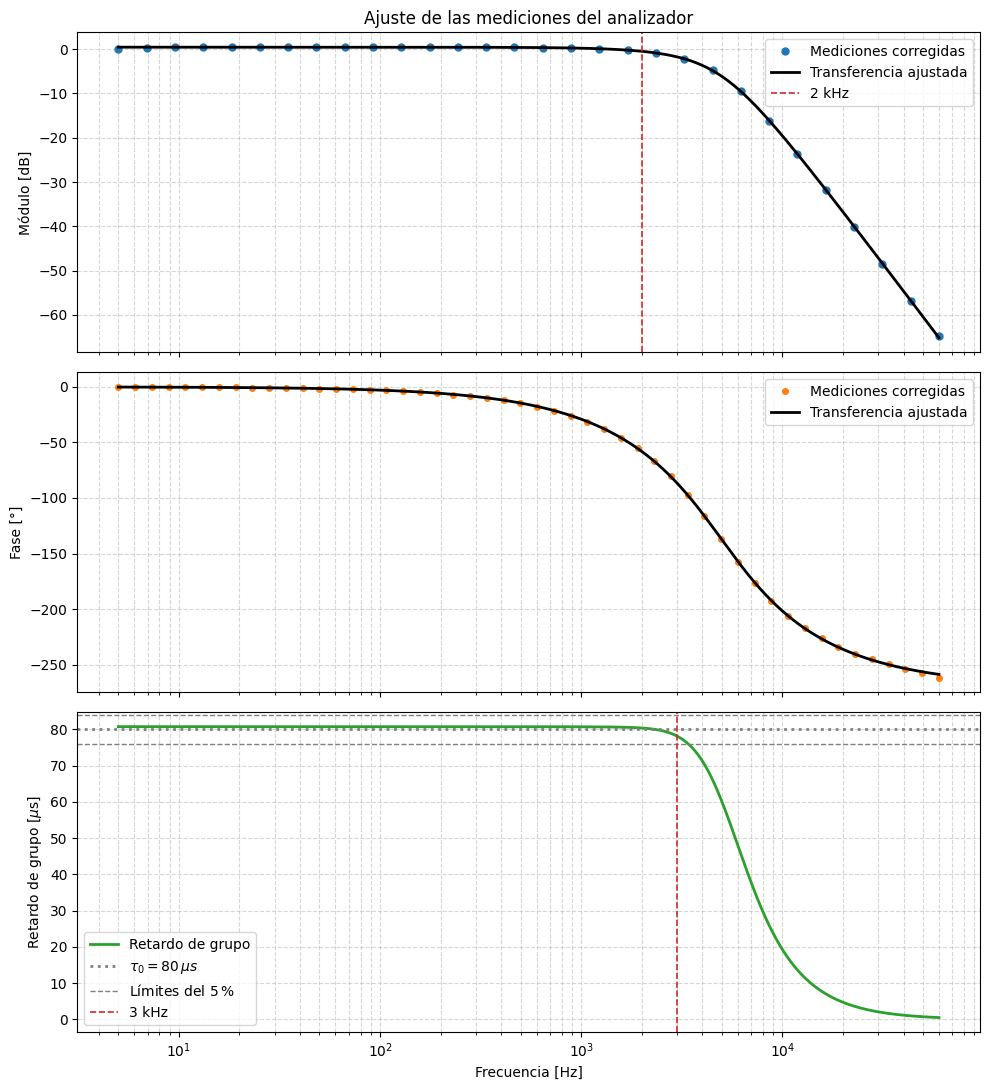


Valores característicos del ajuste
----------------------------------
Módulo absoluto a 2 kHz = -0.502 dB
Atenuación respecto de continua a 2 kHz = 0.929 dB
Retardo de grupo en baja frecuencia = 80.776 µs
Retardo de grupo a 3 kHz = 78.142 µs
Desvío entre baja frecuencia y 3 kHz = 3.261 %
Error respecto de 80 µs a 3 kHz = 2.323 %
Error RMS de módulo = 0.103 dB
Error RMS de fase = 0.509°


In [11]:
# ============================================================
# Modelo de transferencia de tercer orden
# ============================================================

def respuesta_modelo(f, theta):
    """
    Modelo utilizado:

                         G·p1·w0²
    H(s) = ------------------------------------
            (s + p1)(s² + (w0/Q)s + w0²)

    Parámetros:
        theta[0] = ganancia en continua [dB]
        theta[1] = ln(p1)
        theta[2] = ln(w0)
        theta[3] = ln(Q)
    """

    ganancia_db = theta[0]

    p1, w0, Q = np.exp(theta[1:])

    G = 10**(ganancia_db / 20)

    s = 1j * 2 * np.pi * np.asarray(f)

    H = (
        G * p1 * w0**2
        /
        (
            (s + p1)
            *
            (
                s**2
                + (w0 / Q) * s
                + w0**2
            )
        )
    )

    return H


# ============================================================
# Función de error para el ajuste
# ============================================================

def residuos(theta):

    # Evaluación en las frecuencias del módulo
    H_modulo = respuesta_modelo(
        f_modulo,
        theta
    )

    # Evaluación en las frecuencias de la fase
    H_fase = respuesta_modelo(
        f_fase,
        theta
    )

    modulo_modelo_db = 20 * np.log10(
        np.abs(H_modulo)
    )

    fase_modelo_deg = np.rad2deg(
        np.unwrap(
            np.angle(H_fase)
        )
    )

    # Los errores se dividen por valores representativos
    # de la incertidumbre de cada medición.
    error_modulo = (
        modulo_modelo_db
        - modulo_corregido_db
    ) / 0.15

    error_fase = (
        fase_modelo_deg
        - fase_corregida_deg
    ) / 1.5

    return np.concatenate([
        error_modulo,
        error_fase
    ])


# ============================================================
# Valores iniciales
# ============================================================

# Región utilizada para estimar la ganancia de la meseta.
zona_pasante = (
    (f_modulo >= 25)
    & (f_modulo <= 200)
)

ganancia_inicial_db = np.mean(
    modulo_corregido_db[zona_pasante]
)

# Parámetros obtenidos en el diseño teórico
p1_inicial = 29027.3
w0_inicial = 31769.3
Q_inicial = 0.691

theta_inicial = np.array([
    ganancia_inicial_db,
    np.log(p1_inicial),
    np.log(w0_inicial),
    np.log(Q_inicial)
])


# ============================================================
# Ajuste por mínimos cuadrados
# ============================================================

resultado = least_squares(
    residuos,
    theta_inicial,
    loss="linear"
)


# Recuperación de los parámetros ajustados
ganancia_ajustada_db = resultado.x[0]

p1_aj, w0_aj, Q_aj = np.exp(
    resultado.x[1:]
)

G_aj = 10**(
    ganancia_ajustada_db / 20
)


# ============================================================
# Construcción de la transferencia ajustada
# ============================================================

a_aj = w0_aj / Q_aj

num_aj = np.array([
    G_aj * p1_aj * w0_aj**2
])

den_aj = np.array([
    1,
    p1_aj + a_aj,
    w0_aj**2 + p1_aj * a_aj,
    p1_aj * w0_aj**2
])

H_ajustada = TransferFunction(
    num_aj,
    den_aj
)


# ============================================================
# Presentación de los parámetros
# ============================================================

print("Parámetros de la transferencia ajustada")
print("----------------------------------------")

print(
    f"Ganancia en continua = "
    f"{ganancia_ajustada_db:.4f} dB"
)

print(
    f"Ganancia lineal G = "
    f"{G_aj:.6f}"
)

print(
    f"p1 = "
    f"{p1_aj:.3f} rad/s"
)

print(
    f"w0 = "
    f"{w0_aj:.3f} rad/s"
)

print(
    f"Q = "
    f"{Q_aj:.6f}"
)

print("\nCoeficientes de la transferencia:")

print(
    f"Numerador = "
    f"{num_aj[0]:.6e}"
)

print(
    "Denominador = "
    f"[1, "
    f"{den_aj[1]:.6e}, "
    f"{den_aj[2]:.6e}, "
    f"{den_aj[3]:.6e}]"
)

print("\nTransferencia ajustada:")

print(
    f"H(s) = {num_aj[0]:.6e} / "
    f"(s³ + {den_aj[1]:.6e}s² "
    f"+ {den_aj[2]:.6e}s "
    f"+ {den_aj[3]:.6e})"
)


# ============================================================
# Curvas continuas de la transferencia ajustada
# ============================================================

f_min = min(
    f_modulo.min(),
    f_fase.min()
)

f_max = max(
    f_modulo.max(),
    f_fase.max()
)

f_grafico = np.logspace(
    np.log10(f_min),
    np.log10(f_max),
    2500
)

H_grafico = respuesta_modelo(
    f_grafico,
    resultado.x
)

modulo_ajustado_db = 20 * np.log10(
    np.abs(H_grafico)
)

fase_ajustada_deg = np.rad2deg(
    np.unwrap(
        np.angle(H_grafico)
    )
)


# ============================================================
# Función para calcular el retardo de grupo
# ============================================================

def retardo_grupo(f, p1, w0, Q):
    """
    Retardo de grupo del producto de una etapa
    de primer orden y una etapa de segundo orden.

    El resultado se entrega en segundos.
    """

    w = 2 * np.pi * np.asarray(f)

    a = w0 / Q

    # Aporte de la etapa de primer orden
    tau_1 = (
        p1
        /
        (p1**2 + w**2)
    )

    # Aporte de la etapa de segundo orden
    tau_2 = (
        a * (w0**2 + w**2)
        /
        (
            (w0**2 - w**2)**2
            + (a * w)**2
        )
    )

    return tau_1 + tau_2


# Retardo de grupo de la transferencia ajustada
retardo_ajustado_us = (
    retardo_grupo(
        f_grafico,
        p1_aj,
        w0_aj,
        Q_aj
    )
    * 1e6
)


# ============================================================
# Gráficos de las mediciones y del ajuste
# ============================================================

fig, ax = plt.subplots(
    3,
    1,
    figsize=(10, 11),
    sharex=True
)


# ------------------------------------------------------------
# Módulo
# ------------------------------------------------------------

ax[0].semilogx(
    f_modulo,
    modulo_corregido_db,
    "o",
    markersize=5,
    color="tab:blue",
    label="Mediciones corregidas"
)

ax[0].semilogx(
    f_grafico,
    modulo_ajustado_db,
    "-",
    linewidth=2,
    color="black",
    label="Transferencia ajustada"
)

ax[0].axvline(
    2000,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label="2 kHz"
)

ax[0].set_ylabel(
    "Módulo [dB]"
)

ax[0].set_title(
    "Ajuste de las mediciones del analizador"
)

ax[0].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[0].legend()


# ------------------------------------------------------------
# Fase
# ------------------------------------------------------------

ax[1].semilogx(
    f_fase,
    fase_corregida_deg,
    "o",
    markersize=4,
    color="tab:orange",
    label="Mediciones corregidas"
)

ax[1].semilogx(
    f_grafico,
    fase_ajustada_deg,
    "-",
    linewidth=2,
    color="black",
    label="Transferencia ajustada"
)

ax[1].set_ylabel(
    "Fase [°]"
)

ax[1].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[1].legend()


# ------------------------------------------------------------
# Retardo de grupo
# ------------------------------------------------------------

ax[2].semilogx(
    f_grafico,
    retardo_ajustado_us,
    linewidth=2,
    color="tab:green",
    label="Retardo de grupo"
)

# Retardo nominal
ax[2].axhline(
    80,
    color="gray",
    linestyle=":",
    linewidth=2,
    label=r"$\tau_0=80\,\mu s$"
)

# Límites de ±5 % respecto de 80 µs
ax[2].axhline(
    76,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=r"Límites del $5\,\%$"
)

ax[2].axhline(
    84,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax[2].axvline(
    3000,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label="3 kHz"
)

ax[2].set_xlabel(
    "Frecuencia [Hz]"
)

ax[2].set_ylabel(
    r"Retardo de grupo [$\mu$s]"
)

ax[2].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax[2].legend()

plt.tight_layout()
plt.show()


# ============================================================
# Valores característicos
# ============================================================

# Módulo absoluto a 2 kHz
H_2k = respuesta_modelo(
    np.array([2000.0]),
    resultado.x
)[0]

modulo_2k_db = 20 * np.log10(
    np.abs(H_2k)
)


# Como la ganancia en continua no es 0 dB,
# la atenuación se calcula respecto de esa ganancia.
atenuacion_relativa_2k_db = (
    ganancia_ajustada_db
    - modulo_2k_db
)


# Retardo de grupo en baja frecuencia
retardo_baja_us = (
    retardo_grupo(
        np.array([0.0]),
        p1_aj,
        w0_aj,
        Q_aj
    )[0]
    * 1e6
)


# Retardo de grupo a 3 kHz
retardo_3k_us = (
    retardo_grupo(
        np.array([3000.0]),
        p1_aj,
        w0_aj,
        Q_aj
    )[0]
    * 1e6
)


# Variación entre baja frecuencia y 3 kHz.
# Este valor evalúa la constancia del retardo.
desvio_relativo_3k = (
    abs(retardo_baja_us - retardo_3k_us)
    / retardo_baja_us
) * 100


# Diferencia respecto del valor nominal de 80 µs.
desvio_nominal_3k = (
    abs(retardo_3k_us - 80.0)
    / 80.0
) * 100


# ============================================================
# Cálculo del error RMS
# ============================================================

H_modulo_puntos = respuesta_modelo(
    f_modulo,
    resultado.x
)

H_fase_puntos = respuesta_modelo(
    f_fase,
    resultado.x
)

error_rms_modulo = np.sqrt(
    np.mean(
        (
            20 * np.log10(
                np.abs(H_modulo_puntos)
            )
            - modulo_corregido_db
        )**2
    )
)

error_rms_fase = np.sqrt(
    np.mean(
        (
            np.rad2deg(
                np.unwrap(
                    np.angle(H_fase_puntos)
                )
            )
            - fase_corregida_deg
        )**2
    )
)


# ============================================================
# Presentación de los valores característicos
# ============================================================

print("\nValores característicos del ajuste")
print("----------------------------------")

print(
    f"Módulo absoluto a 2 kHz = "
    f"{modulo_2k_db:.3f} dB"
)

print(
    f"Atenuación respecto de continua a 2 kHz = "
    f"{atenuacion_relativa_2k_db:.3f} dB"
)

print(
    f"Retardo de grupo en baja frecuencia = "
    f"{retardo_baja_us:.3f} µs"
)

print(
    f"Retardo de grupo a 3 kHz = "
    f"{retardo_3k_us:.3f} µs"
)

print(
    f"Desvío entre baja frecuencia y 3 kHz = "
    f"{desvio_relativo_3k:.3f} %"
)

print(
    f"Error respecto de 80 µs a 3 kHz = "
    f"{desvio_nominal_3k:.3f} %"
)

print(
    f"Error RMS de módulo = "
    f"{error_rms_modulo:.3f} dB"
)

print(
    f"Error RMS de fase = "
    f"{error_rms_fase:.3f}°"
)

# <ins>Comparación final de resultados

Para evaluar el comportamiento del filtro se compararon los siguientes cuatro casos:

1. Transferencia ideal obtenida durante el diseño teórico.
2. Transferencia calculada con los valores reales de los componentes.
3. Transferencia ajustada a partir de las mediciones con el osciloscopio.
4. Transferencia ajustada a partir de las mediciones con el analizador de audio.

Todas corresponden a filtros pasabajos de tercer orden.

## <ins>Transferencias comparadas

La transferencia ideal es:

$$
H_{\mathrm{ideal}}(s)=
\frac{2.9297\times10^{13}}
{s^3+7.5000\times10^4s^2+2.3438\times10^9s+2.9297\times10^{13}}
$$

Utilizando los valores reales de los componentes indicados en la simulación se obtiene:

$$
H_{\mathrm{real}}(s)=
\frac{2.8002\times10^{13}}
{s^3+7.4081\times10^4s^2+2.2675\times10^9s+2.8002\times10^{13}}
$$

El ajuste de las mediciones realizadas con el osciloscopio produjo:

$$
H_{\mathrm{osc}}(s)=
\frac{2.8258\times10^{13}}
{s^3+7.3848\times10^4s^2+2.3045\times10^9s+2.8258\times10^{13}}
$$

Finalmente, el ajuste de los datos obtenidos con el analizador de audio dio:

$$
H_{\mathrm{audio}}(s)=
\frac{2.9689\times10^{13}}
{s^3+7.3726\times10^4s^2+2.2831\times10^9s+2.8264\times10^{13}}
$$

En la transferencia obtenida con el analizador, el numerador y el término independiente del denominador no son iguales. Esto se debe a la ganancia residual de aproximadamente $0.427\,\mathrm{dB}$ presente luego de restar exactamente el *offset* de $54\,\mathrm{dB}$.

## <ins>Comparación de valores característicos

La atenuación a $2\,\mathrm{kHz}$ se calculó respecto de la ganancia de cada transferencia en baja frecuencia:

$$
A_{2\,\mathrm{kHz}}
=
|H(0)|_{\mathrm{dB}}
-
|H(2\,\mathrm{kHz})|_{\mathrm{dB}}
$$

El desvío del retardo de grupo se calculó mediante:

$$
\varepsilon_\tau
=
\frac{
\left|\tau_g(0)-\tau_g(3\,\mathrm{kHz})\right|
}{
\tau_g(0)
}
\cdot100
$$

| Caso | Ganancia BF [dB] | Atenuación 2 kHz [dB] | Retardo BF [µs] | Retardo 3 kHz [µs] | Desvío [%] |
|:--|--:|--:|--:|--:|--:|
| Ideal | 0.000 | 0.913 | 80.000 | 77.458 | 3.18 |
| Componentes reales | 0.000 | 0.917 | 80.975 | 78.866 | 2.60 |
| Ajuste del osciloscopio | 0.000 | 0.991 | 81.552 | 77.392 | 5.10 |
| Ajuste del analizador | 0.427 | 0.929 | 80.776 | 78.142 | 3.26 |
| Especificación | — | ≤ 1.000 | 80.000 | — | ≤ 5.00 |

## <ins>Comparación gráfica

A continuación se representan simultáneamente las respuestas de módulo, fase y retardo de grupo de las cuatro transferencias. Esto permite observar directamente las diferencias entre el diseño ideal, la simulación con componentes reales y los dos ajustes experimentales.

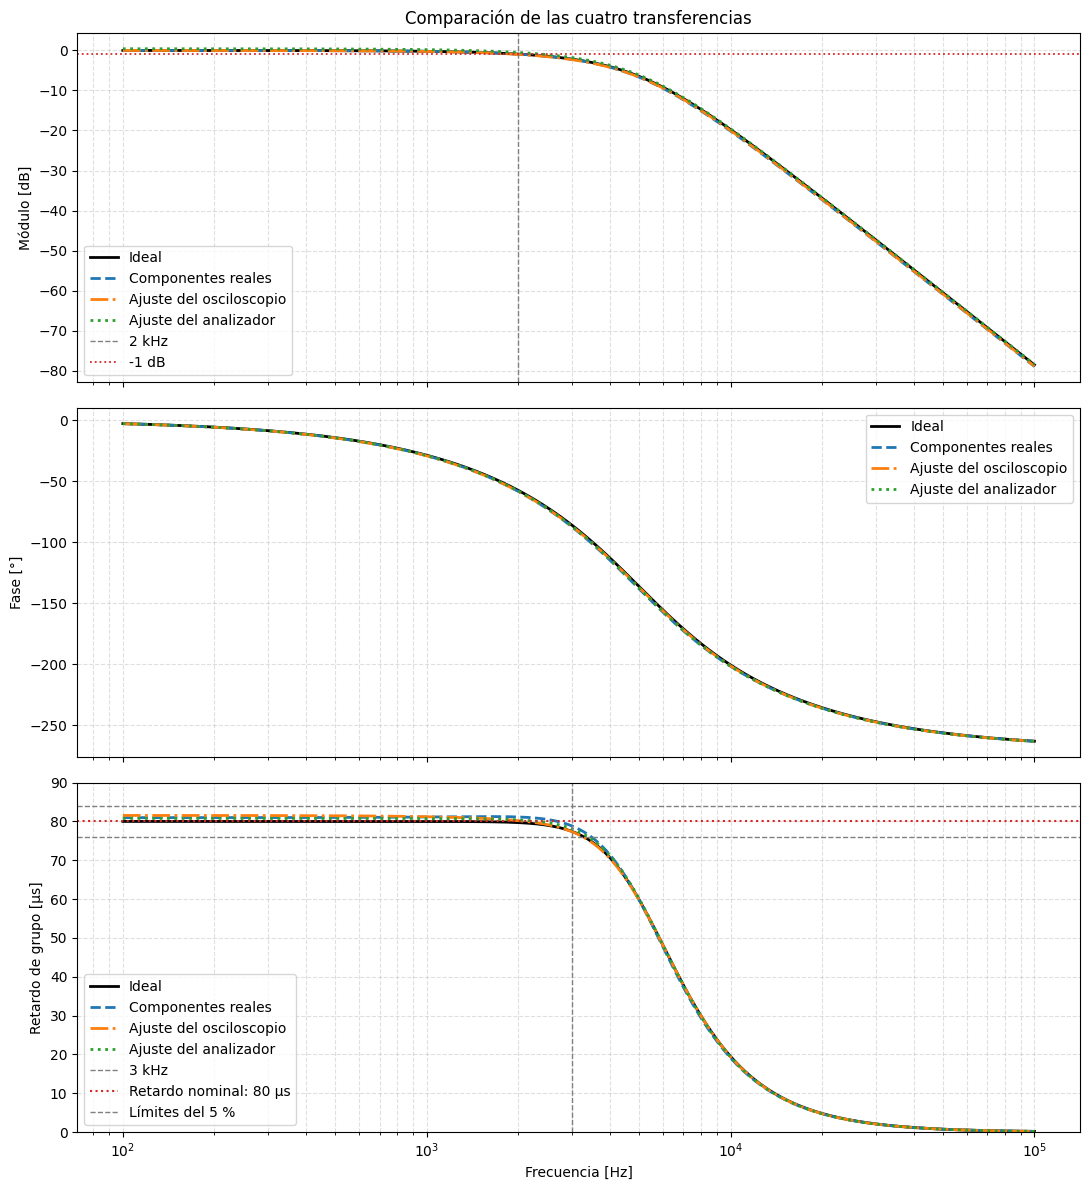

In [15]:
# ============================================================
# Coeficientes de las cuatro transferencias
# ============================================================

transferencias = {
    "Ideal": {
        "num": [2.9297e13],
        "den": [
            1,
            7.5000e4,
            2.3438e9,
            2.9297e13
        ],
        "color": "black",
        "estilo": "-"
    },

    "Componentes reales": {
        "num": [2.8002e13],
        "den": [
            1,
            7.4081e4,
            2.2675e9,
            2.8002e13
        ],
        "color": "tab:blue",
        "estilo": "--"
    },

    "Ajuste del osciloscopio": {
        "num": [2.8258e13],
        "den": [
            1,
            7.3848e4,
            2.3045e9,
            2.8258e13
        ],
        "color": "tab:orange",
        "estilo": "-."
    },

    "Ajuste del analizador": {
        "num": [2.9689e13],
        "den": [
            1,
            7.3726e4,
            2.2831e9,
            2.8264e13
        ],
        "color": "tab:green",
        "estilo": ":"
    }
}


# ============================================================
# Vector de frecuencias
# ============================================================

f = np.logspace(
    np.log10(100),
    np.log10(100000),
    4000
)

w = 2 * np.pi * f


# ============================================================
# Creación de los gráficos
# ============================================================

fig, ax = plt.subplots(
    3,
    1,
    figsize=(11, 12),
    sharex=True
)


# ============================================================
# Cálculo y representación de cada transferencia
# ============================================================

for nombre, datos in transferencias.items():

    num = np.asarray(
        datos["num"],
        dtype=float
    )

    den = np.asarray(
        datos["den"],
        dtype=float
    )

    # Respuesta en frecuencia
    _, H = freqs(
        num,
        den,
        worN=w
    )

    # Módulo en dB
    modulo_db = 20 * np.log10(
        np.abs(H)
    )

    # Fase desenvolvida
    fase_rad = np.unwrap(
        np.angle(H)
    )

    fase_deg = np.rad2deg(
        fase_rad
    )

    # Retardo de grupo:
    # tau_g = -d(phi)/d(omega)
    retardo_us = (
        -np.gradient(
            fase_rad,
            w
        )
        * 1e6
    )


    # --------------------------------------------------------
    # Gráfico de módulo
    # --------------------------------------------------------

    ax[0].semilogx(
        f,
        modulo_db,
        color=datos["color"],
        linestyle=datos["estilo"],
        linewidth=2,
        label=nombre
    )


    # --------------------------------------------------------
    # Gráfico de fase
    # --------------------------------------------------------

    ax[1].semilogx(
        f,
        fase_deg,
        color=datos["color"],
        linestyle=datos["estilo"],
        linewidth=2,
        label=nombre
    )


    # --------------------------------------------------------
    # Gráfico de retardo de grupo
    # --------------------------------------------------------

    ax[2].semilogx(
        f,
        retardo_us,
        color=datos["color"],
        linestyle=datos["estilo"],
        linewidth=2,
        label=nombre
    )


# ============================================================
# Configuración del gráfico de módulo
# ============================================================

ax[0].axvline(
    2000,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="2 kHz"
)

ax[0].axhline(
    -1,
    color="tab:red",
    linestyle=":",
    linewidth=1.3,
    label="-1 dB"
)

ax[0].set_ylabel(
    "Módulo [dB]"
)

ax[0].set_title(
    "Comparación de las cuatro transferencias"
)

ax[0].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

ax[0].legend(
    loc="best"
)


# ============================================================
# Configuración del gráfico de fase
# ============================================================

ax[1].set_ylabel(
    "Fase [°]"
)

ax[1].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

ax[1].legend(
    loc="best"
)


# ============================================================
# Configuración del gráfico de retardo de grupo
# ============================================================

ax[2].axvline(
    3000,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="3 kHz"
)

ax[2].axhline(
    80,
    color="tab:red",
    linestyle=":",
    linewidth=1.5,
    label="Retardo nominal: 80 µs"
)

ax[2].axhline(
    76,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Límites del 5 %"
)

ax[2].axhline(
    84,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax[2].set_xlabel(
    "Frecuencia [Hz]"
)

ax[2].set_ylabel(
    "Retardo de grupo [µs]"
)

ax[2].set_ylim(
    0,
    90
)

ax[2].grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

ax[2].legend(
    loc="best"
)


plt.tight_layout()
plt.show()

## <ins> Análisis de los resultados

Las cuatro curvas de módulo presentan un comportamiento muy similar. Las diferencias son pequeñas dentro de la banda pasante y se hacen algo más visibles a medida que aumenta la frecuencia.

La transferencia obtenida con los componentes reales permanece muy próxima a la transferencia ideal. Esto indica que el ajuste de las resistencias permitió compensar adecuadamente las diferencias entre los valores nominales y los valores medidos de los componentes.

La respuesta obtenida con el analizador de audio presenta un desplazamiento vertical de aproximadamente $0.427\,\mathrm{dB}$ debido a la ganancia residual que permanece luego de restar el *offset* de $54\,\mathrm{dB}$. Sin embargo, su atenuación relativa a $2\,\mathrm{kHz}$ es de $0.929\,\mathrm{dB}$, por lo que cumple con la especificación.

Las curvas de fase también presentan una buena concordancia. Esto confirma que los cuatro modelos poseen una ubicación de polos similar y, por lo tanto, un comportamiento dinámico equivalente.

En el gráfico de retardo de grupo se observa que las cuatro transferencias se mantienen próximas a $80\,\mu\mathrm{s}$ en baja frecuencia. La transferencia ideal, la simulación con componentes reales y el ajuste del analizador permanecen dentro del límite del $5\%$ a $3\,\mathrm{kHz}$.

El ajuste del osciloscopio presenta un desvío de aproximadamente $5.10\%$, apenas por encima del límite establecido. Esta diferencia puede atribuirse a la resolución de la medición temporal, a la cantidad limitada de puntos y a la determinación manual del retardo entre las señales.

## <ins> Conclusión final

Los resultados teóricos, simulados y experimentales presentan una buena concordancia. La implementación real conserva el comportamiento esperado de un filtro Bessel de tercer orden, con una respuesta de módulo sin resonancias y un retardo de grupo aproximadamente constante dentro de la banda de interés.

La medición realizada con el analizador de audio es la que permite caracterizar con mayor precisión el comportamiento global del filtro, debido a la mayor cantidad de puntos y a la medición automática del módulo y de la fase.

Según el ajuste realizado con estos datos, el filtro presenta una atenuación relativa de $0.929\,\mathrm{dB}$ a $2\,\mathrm{kHz}$ y un desvío del retardo de grupo de $3.26\%$ a $3\,\mathrm{kHz}$. Por lo tanto, cumple con las dos especificaciones establecidas.

En conclusión, el filtro construido satisface los requisitos propuestos. Las pequeñas diferencias respecto de la transferencia ideal son compatibles con las tolerancias de los componentes, el comportamiento no ideal de los amplificadores operacionales y las incertidumbres propias de las mediciones experimentales.